# Курс "Практикум по математической статистике"
# 3 курс ФПМИ МФТИ, осень 2025
## Практическое задание 4. Регрессионный анализ
### Дедлайн --- 29 ноября 16:00

Мы предлагаем выполнять задания прямо в этом ноутбуке. Пожалуйста, не стирайте условия задач.


В этом и последующих заданиях вам потребуется выполнять генерацию случайных величин из некоторого распределения. Для этого вам понадобится библиотека `scipy.stats`. Мы настоятельно рекомендуем для генерации выборок использовать именно эту библиотеку.

Настоятельно рекомендуемая форма оформления домашних заданий — это Jupyter Notebook c:

* условием задачи,
* решением (если требуется некоторый теоретический вывод),
* описанием плана решения, который потом реализуется в коде,
* собственно кодом,
* построенными графиками (если это требуется) и **выводом**, который как правило должен заключаться в объяснении практических результатов с использованием теоретических фактов. ***Вывод требуется даже в том случае, если в условии об этом явно не сказано!***
* некоторыми другими вещами, если об этом будет указано в задании.

Оценка за каждую задачу складывается из правильного выполнения всех этих пунктов. Закрывая на них глаза, вы сознательно понижаете свою оценку.

In [1]:
import numpy as np
from scipy import stats as sps
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(font_scale=1.4, style='whitegrid')
%config InlineBackend.figure_format='retina'

*Замечание*. Как и в прошлом задании, при проверке гипотез мы используем уровень значимости $\alpha=0.05$.

## Задача 1. Трамвайчик

*Данная задача стоит 10 баллов.*

Важно: в учебных целях в первой задаче **запрещено** использовать готовые реализации линейной регрессии и методов для неё (например, из пакета *scikit-learn*).

На полигоне испытывается новая модель трамвая. В одном из испытании работы двигателя проверяется, что движение трамвая равномерно. Для проведения теста на трамвай установлен датчик, посекундно измеряющий пройденное расстояние.

Записи датчика можно описать такой моделью:

 $$X_i = \beta_1+i\beta_2+\varepsilon_0+\ldots+\varepsilon_i,\, i= 0, 1, \ldots, n$$

где $X_i$ --- расстояние, которое проехал трамвай за $i$ секунд. В модели $\beta_1$ --- начальное расстояние, $\beta_2$ --- скорость трамвая, $\varepsilon_0$ --- ошибка начального показания датчика. Отсчет времени идет от предыдущего замера, причем отсчет происходит с ошибкой. Для $i = 0, \ldots, n$ величина $\varepsilon_i$ есть ошибка приращения расстояния, то есть $\varepsilon_i = \varepsilon_i^t \beta_2,$ где $\varepsilon_i^t$ --- ошибка отсчета времени. Все ошибки $\varepsilon_i^t$ независимы и распределены по закону $N(0, \sigma^2)$.

Сведите задачу к линейной модели и найдите оценки наименьших квадратов для начального расстояния $\beta_1$ и скорости $\beta_2,$ а также несмещенную оценку для дисперсии ошибки приращения расстояния, из которой выразите оценку дисперсии отсчета времени $\sigma^2$.

Данные возьмите из файла Regression.csv. Сделайте выводы.

### Решение

Загрузим датасет, содержащий показания датчика.

In [9]:
!pipx install -q gdown
!gdown "https://drive.google.com/uc?id=1pJSA_OGMHu2Ks__Wqf0digi3RAz7Wg7J"

⣟ upgrading shared libraries'gdown' already seems to be installed. Not modifying existing installation in
'/Users/gantulga/.local/pipx/venvs/gdown'. Pass '--force' to force
installation.
Downloading...
From: https://drive.google.com/uc?id=1pJSA_OGMHu2Ks__Wqf0digi3RAz7Wg7J
To: /Users/gantulga/Downloads/regression.csv
100%|██████████████████████████████████████| 9.98k/9.98k [00:00<00:00, 20.0MB/s]


Датасет состоит из 1000 измерений. По смыслу средняя скорость имеет размерность метры в секунду.

In [10]:
X = np.genfromtxt('regression.csv')
print('Размер датасета:', X.shape)
print('Средняя скорость:', X[-1] / X.shape[0])

Размер датасета: (1000,)
Средняя скорость: 12.0408175


Визуализируйте данные и сделайте выводы о том, верно ли что линейная регрессионная модель имеет смысл

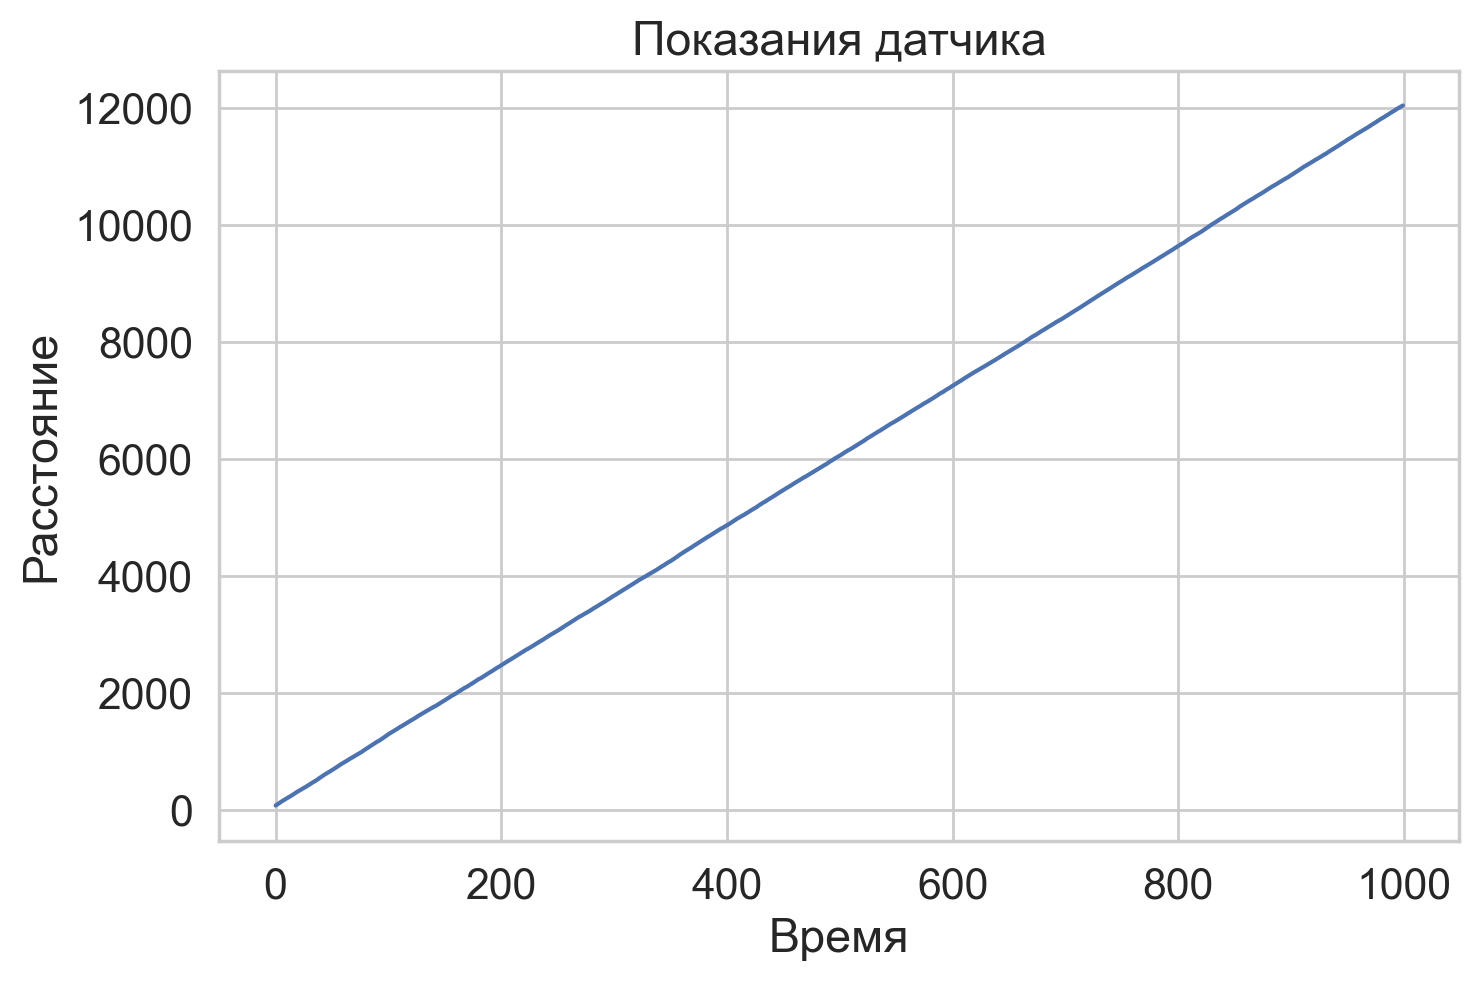

In [18]:
t = np.arange(X.shape[0])

plt.figure(figsize=(8, 5))
plt.plot(t, X, linestyle='-')
plt.xlabel("Время")
plt.ylabel("Расстояние")
plt.title("Показания датчика")
plt.grid(True)
plt.show()

График очевидно линейный - линейная модель выглядит супер логичной.

#### 1. Сведите задачу к гауссовской линейной модели

$$
X_i = \beta_1 + i\beta_2 + \varepsilon_0 + \dots + \varepsilon_i
$$
где 
$$
\varepsilon_i \sim N(0,\sigma^2)
$$ 
независимы.

Введем новые наблюдения:
$$
Y_0 = X_0,\quad
Y_i = X_i - X_{i-1},
$$

Тогда
$$
Y_0 = \beta_1 + \varepsilon_0, \quad
Y_i = \beta_2 + \varepsilon_i,\ i=1,\dots,n,
$$

Это можно записать как линейную модель
$$
Y = Z\beta + \varepsilon, \quad
Y\in\mathbb{R}^{n+1}, \quad
\beta = (\beta_1,\beta_2)^T
$$
$$
Z =
\begin{pmatrix}
1 & 0 \\
0 & 1 \\
0 & 1 \\
\vdots & \vdots \\
0 & 1
\end{pmatrix}
$$

In [19]:
# тут можете пересчитать выборку, если потребуется

Y = np.empty_like(X)
Y[0] = X[0]
Y[1:] = X[1:] - X[:-1]

#### 2. Найдите оценку параметров

Укажите, чему равна матрица (Z в терминах методички) в задаче:

И найдите параметры $\beta_1$, $\beta_2$

Воспользуемся МНК

Оценка МНК (а при нормальных ошибках — и ММП) имеет вид

$$
\hat\beta = (Z^{T} Z)^{-1} Z^{T} Y.
$$
Нетрудно получить, что
$$
ZZ^T = 
\begin{pmatrix}
1 & \dots & 0 \\
\vdots \\
0 & \dots & n
\end{pmatrix}
$$
Откуда
$$
\hat\beta_1= X_0 \qquad
\hat\beta_2 = \frac{1}{n}\sum_{i=1}^n X_i = \frac{X_n - X_0}{n}.
$$

In [20]:
beta_1 = X[0]
beta_2 = (X[-1] - X[0]) / (X.shape[0] - 1)

*Ошибкой* или *остатком* называют разность между наблюдаемым значением целевой величины и предсказанием модели на основе соответствующих признаков. Проверьте, насколько точна модель при помощи подсчёта ошибок. Выведите сами ошибки на график и проанализируйте его.

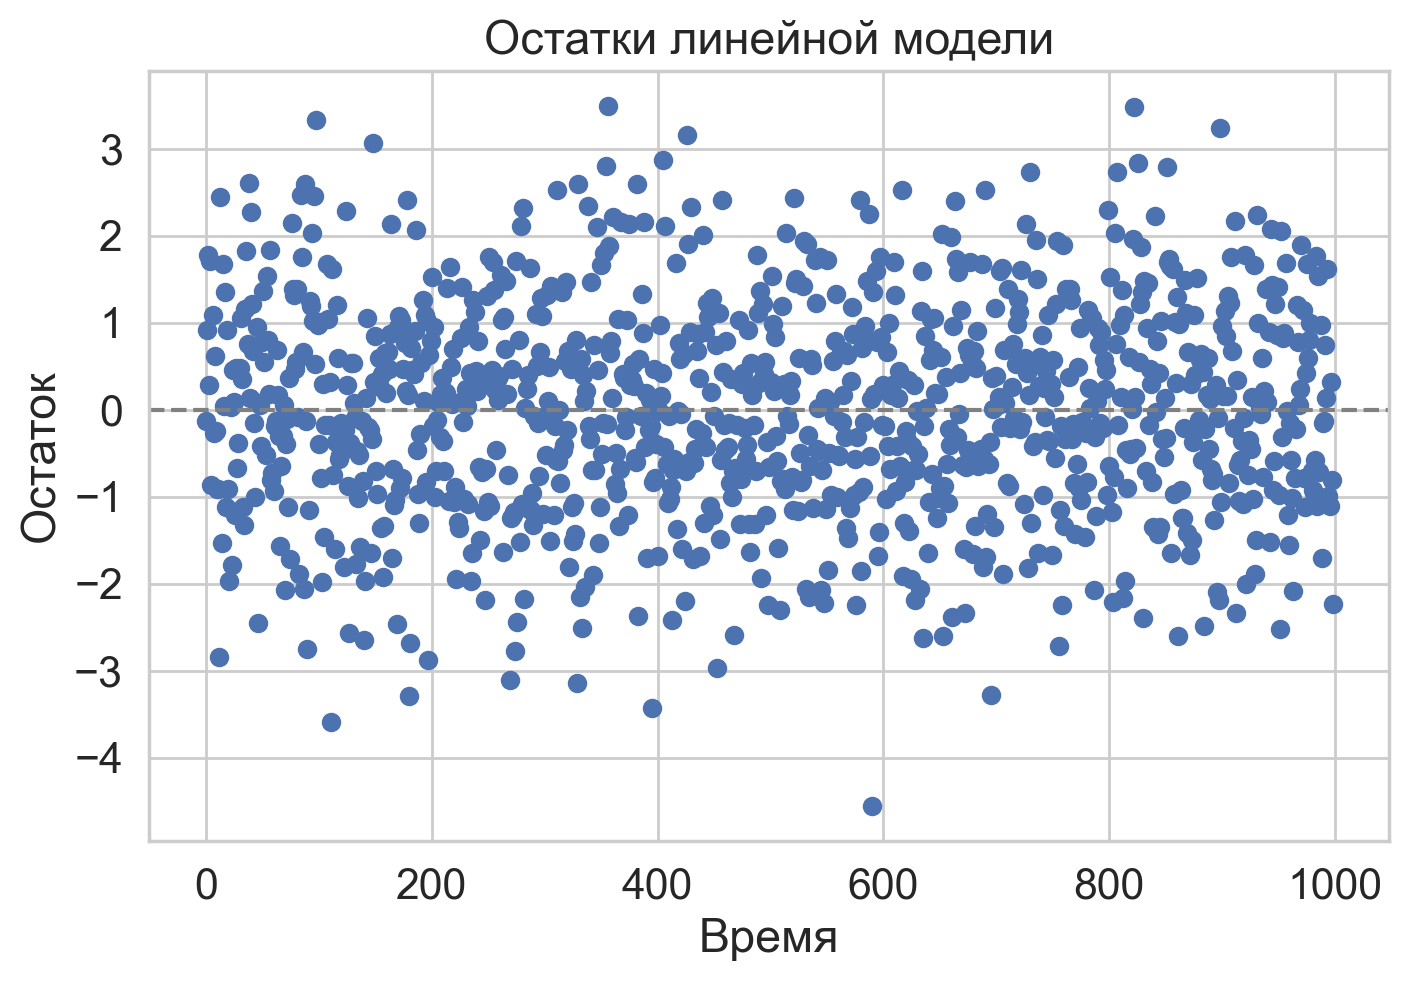

In [33]:
ost = Y[1:] -  beta_2

plt.figure(figsize=(8, 5))
plt.plot(ost, marker='o', linestyle='none')
plt.axhline(0.0, color='gray', linestyle='--')
plt.xlabel("Время")
plt.ylabel("Остаток")
plt.title("Остатки линейной модели")
plt.grid(True)
plt.show()

Совпали не полностью, но это и есть наши остатки , однако они там в допустимом диапазоне

Проверьте, что ошибка нормальна. Для этого можно использовать QQ-plot. Если хотите, можете использовать критерии нормальности


Посчитаю ошибки на X и на Y
1) на X
2) на Y

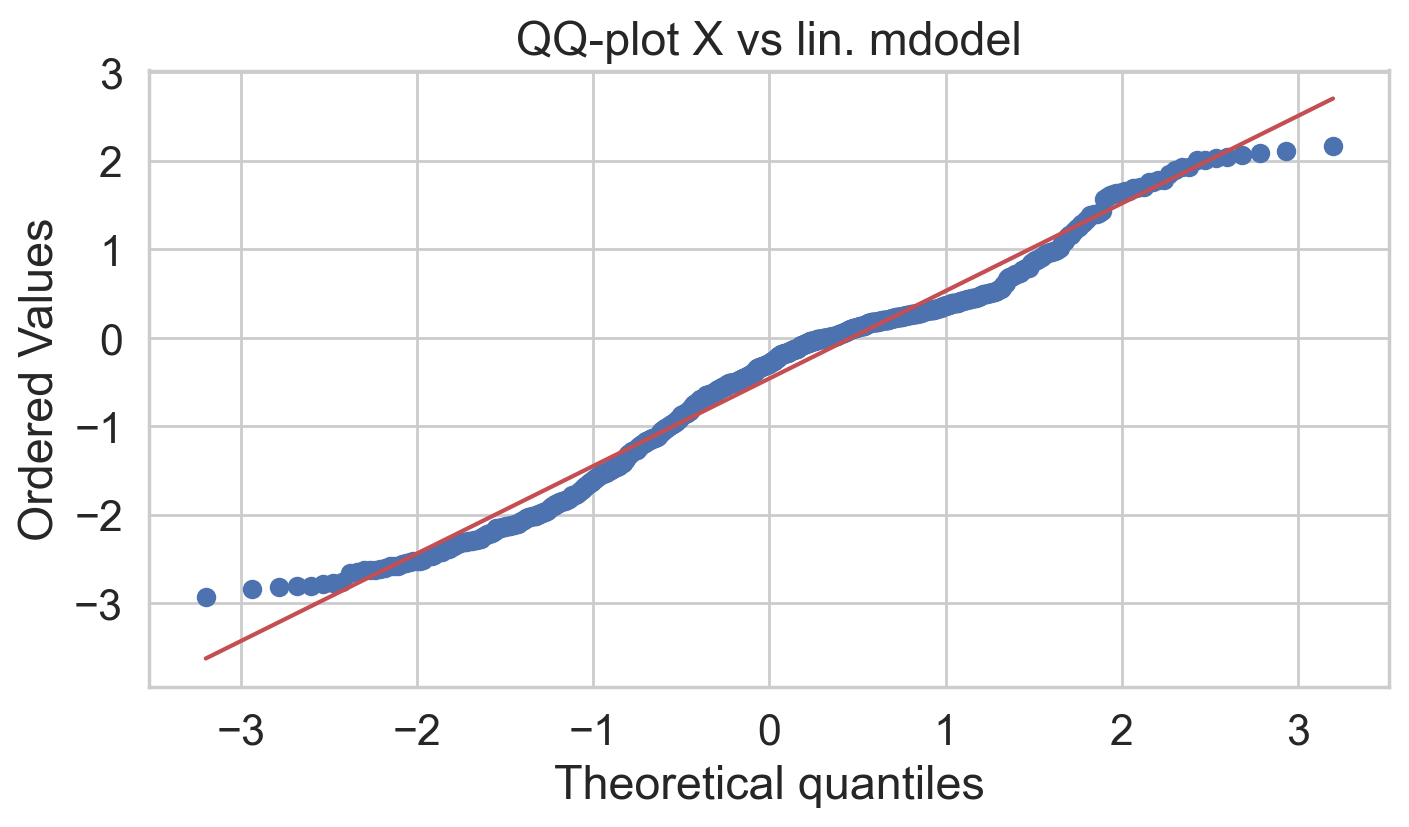

In [56]:
error_1 = X - (beta_2 * np.arange(X.shape[0]) + beta_1)
plt.figure(figsize=(8, 4))
sps.probplot(error_1 / error_1.std(ddof = 2), dist="norm", plot=plt)
plt.title("QQ-plot X vs lin. mdodel")
plt.show()

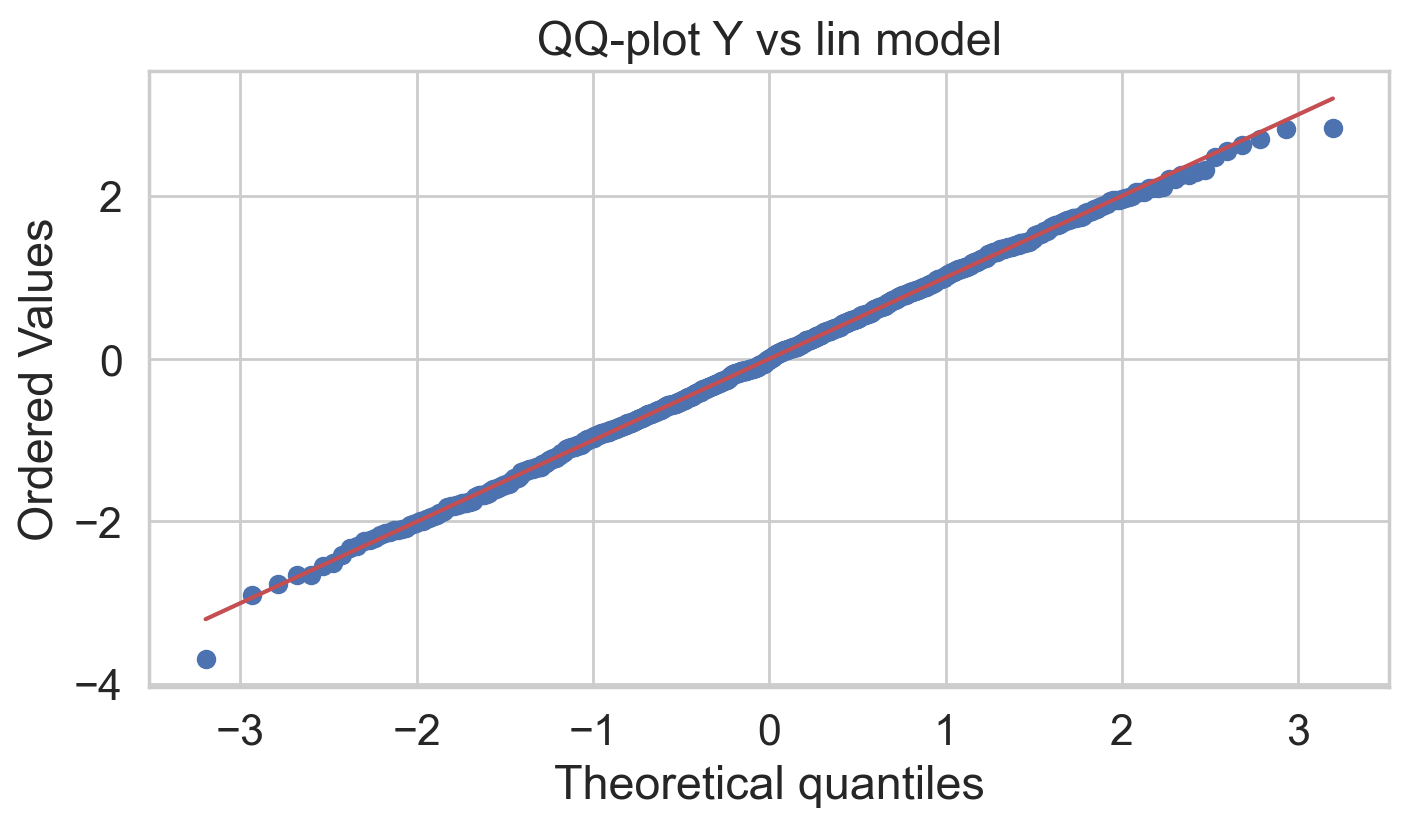

In [57]:
error_2 = Y - np.array([
    beta_1 if i == 0 else beta_2 for i in range(len(X))
])

plt.figure(figsize=(8, 4))
sps.probplot(error_2 / error_2.std(ddof = 2), dist="norm", plot=plt)
plt.title("QQ-plot Y vs lin model")
plt.show()


1) как мы видим ошибка не похожа на нормальную от слова совсем, оно и не мудрено - так-то ошибка в нашем случае имеет накопительный эффект
2) тут они совсем нормальные, которые просто пропорцианальны $\varepsilon$ - они iid 

Бонусная часть про робастность (+5 баллов):

Возможно измерения в задаче содержат разные аномалии, что плохо скажется на оценке наименьших квадратов. Попробуйте применить знания из второго практического задания о робастных оценках и построить оценку с BP выше нуля разными методами. Такие методы называются "робастной регрессией", но определение M-оценки в них то же, что и в обычной робастной статистике.

#### 3. Оцените дисперсию ошибки отсчёта времени $\varepsilon_i^t$.

Найдите *несмещённую* оценку дисперсии ошибки приращения расстояния $\varepsilon_i$. По ней найдите оценку дисперсии ошибки отсчёта времени $\varepsilon_i^t$.

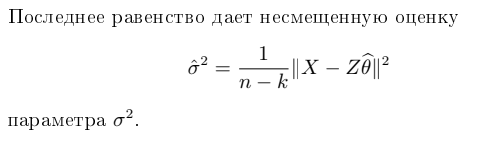

В нашем случае это выражается как 
$$
\hat{\sigma}^2_\varepsilon =
\frac{1}{n-2}\sum_{i=1}^{n}\left(Y_i - \hat{\beta}_2\right)^2.
$$
Очевидно, что 
$$
\varepsilon_i = \beta_2 \varepsilon_i^t
$$
Тогда
$$
\hat{\sigma}^2_{\varepsilon, t} =
\frac{1}{(n-2) \hat\beta_2 ^2}\sum_{i=1}^{n}\left(Y_i - \hat{\beta}_2\right)^2.
$$

In [61]:
sigma_hat = (1 / (len(X) - 2)) * (error_2**2).sum() / (beta_2 ** 2)
sigma_hat**0.5

np.float64(0.10316852681376272)

#### 4. Измерьте качество модели (способы измерения можно подчерпнуть из лекций)

для X

In [151]:
t = np.arange(X.shape[0])
mse = np.mean(error_1**2)
mae = np.mean(np.abs(error_1))

rs = np.sum(error_1**2)   
ts = np.sum((X - X.mean())**2) 
r2 = 1 - rs / ts

print("MSE:", mse)
print("MAE:", mae)
print("R^2:", r2)

MSE: 125.60318694750055
MAE: 8.396171579479297
R^2: 0.9999894515651776


для Y

In [150]:
Y_real = Y[1:]
Y_pred = np.full_like(Y_real, beta_2)

mse_Y = np.mean(error_2*2)
mae_Y = np.mean(np.abs(error_2))

rs_Y = np.sum(error_2**2)
ts_Y = np.sum((Y_real - Y_real.mean())**2)
r2_Y  = 1 - rs_Y / ts_Y

print("MSE_Y:", mse_Y)
print("MAE_Y:", mae_Y)
print("R2_Y :", r2_Y)

MSE_Y: 4.831690603168682e-16
MAE_Y: 0.9901533829829695
R2_Y : 0.0


для Х все круто - модель линейна и тд, 8м вообще не ошибка - мы меряем в сотнях

для Y как и ожидалось при предикте константы с отклонением 1


**Вывод:**
Линейная модель была заиспользована там, где в целом она плохо работалась и мы применили трюк. И в целом по итогу нас не очень заботит как это получилось - главное работает
К тому же мы удобным образом выразили ошибку времени от просто ошибки, что также полезно, наверное. Прикольно получилось, что мы забили на ненормальность ошибки X путем все того же трюка получили хороший результат. По итогу трамвайчик у нас движется без ускорения, что мы и ожидали

## Задача 2. Непараметрическая регрессия и метод Надарая-Ватсона

*Данная задача стоит 5 баллов.*

Иногда вытаскивать информативные признаки из данных сложно, а регрессию делать хочется. Тогда можно построить нечто похожее на ядерную оценку плотности, но для регрессионной задачи. Она основана на вычислении значения в новой точке по значениям в соседних точках (похожее Вы видели на курсе машинного обучения, но для классификации и без статистики).

Перед выполнением изучите формулу Надарая-Ватсона из лекции или статьи на Википедии: https://en.wikipedia.org/wiki/Kernel_regression

1) Сгенерируйте выборку для линейной регрессии руками (использовать реальные данные может быть нецелесообразно из-за проблем с визуализацией результата и проклятия размерностей).

Пусть в модели будет одна фича $x$ и по ней вычисляется отклик $y = ax + b + \varepsilon$, где ошибки $\varepsilon$ независимы и нормальны, а параметры $a$ и $b$ выберите сами.

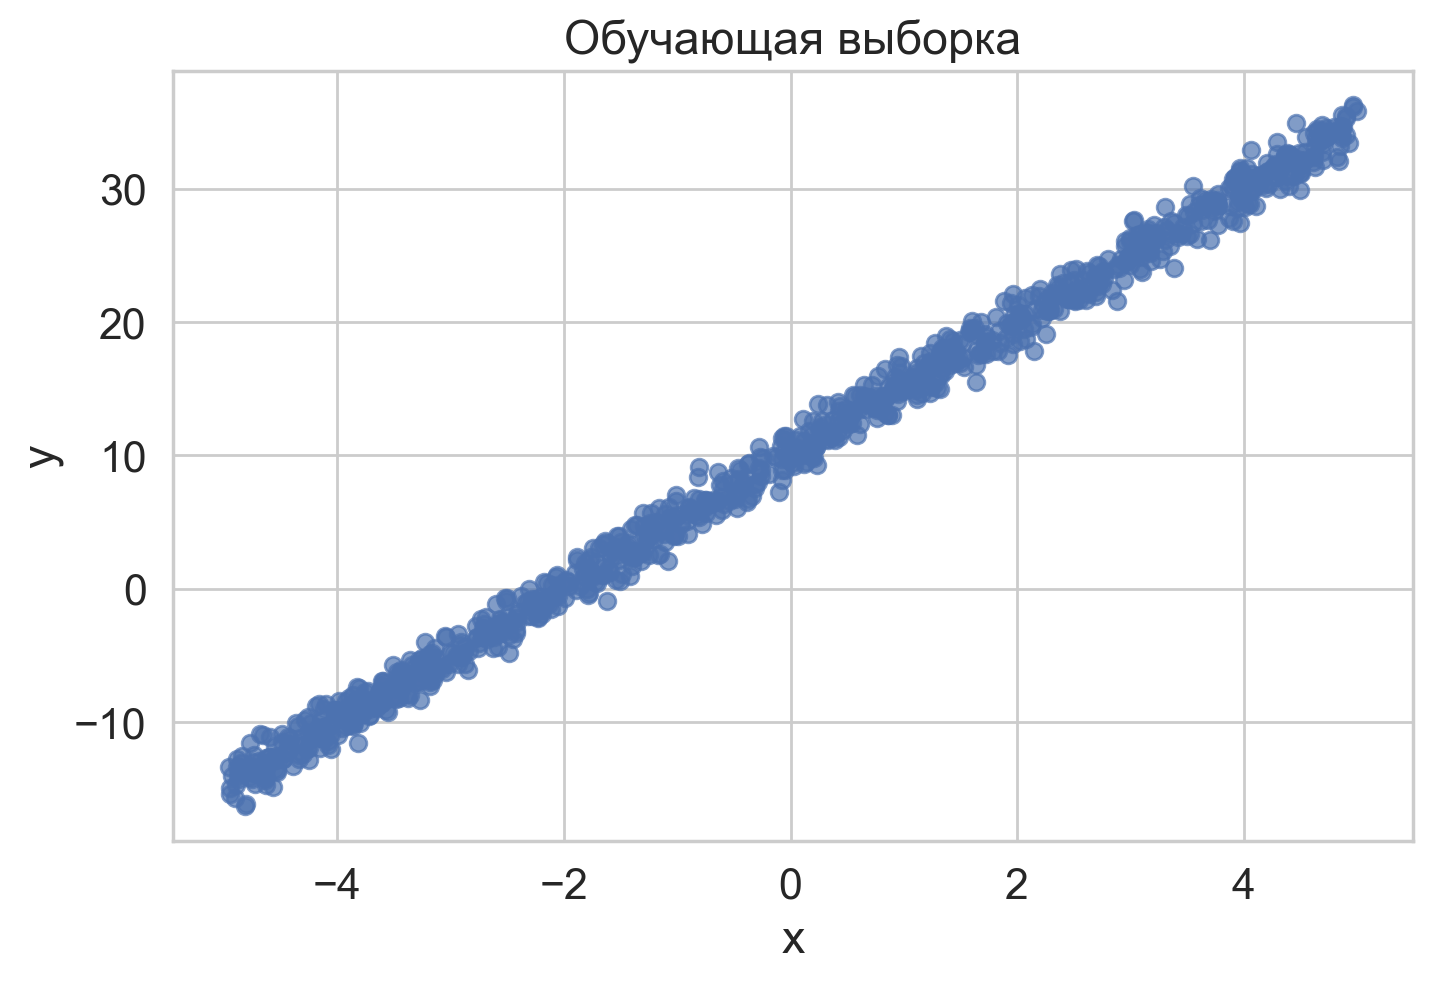

In [102]:
np.random.seed(42)

N = 1000

a_true = 5.0
b_true = 10.0
x_train = np.random.uniform(-5, 5, size=N)

eps = np.random.normal(loc=0.0, scale=1.0, size=N)

y_train = a_true * x_train + b_true + eps

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Обучающая выборка")
plt.grid(True)
plt.show()

Сгенерируйте тестовую выборку тем же способом и посчитайте отклик из формулы Надарая-Ватсона для хотя бы трёх разных ядер (примеры ядер: https://en.wikipedia.org/wiki/Kernel_(statistics)). Сравните ошибки.

In [103]:
def gaussian_kernel(u):
    return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

def logistic_kernel(u):
    return 1 / (np.exp(u) + np.exp(-u) + 2)

def sigmoid_kernel(u):
    return 2 / ((np.exp(u) + np.exp(-u)) * np.pi)

def NW_predict(x_train, y_train, x_test, h, kernel):
    y_pred = np.empty_like(x_test, dtype=float)
    for i, x0 in enumerate(x_test):
        u = (x0 - x_train) / h
        w = kernel(u)
        s = np.sum(w)
        y_pred[i] = np.sum(w * y_train) / s
    return y_pred

In [104]:
def mse(y_test, y_pred):
    return(np.mean((y_test - y_pred)**2))

x_test = np.random.uniform(-5, 5, size=N)
eps_test = np.random.normal(loc=0.0, scale=1.0, size=N)
y_test = a_true * x_test + b_true + eps_test 

h = 0.1
kernels = {
    "gaussian": gaussian_kernel,
    "logistic": logistic_kernel,
    "sigmoid": sigmoid_kernel,
}

mse_res = {}

for name, ker in kernels.items():
    y_pred = NW_predict(x_train, y_train, x_test, h=h, kernel=ker)
    mse_res[name] = mse(y_test, y_pred)

mse_res


{'gaussian': np.float64(1.1001316946676107),
 'logistic': np.float64(1.100056473175127),
 'sigmoid': np.float64(1.097859194095654)}

ошибки примерно равные и в рамках дисперсии

Визуализируйте Ваши предсказания (постройте кривую предсказаний по сетке x с шагом 0.01)

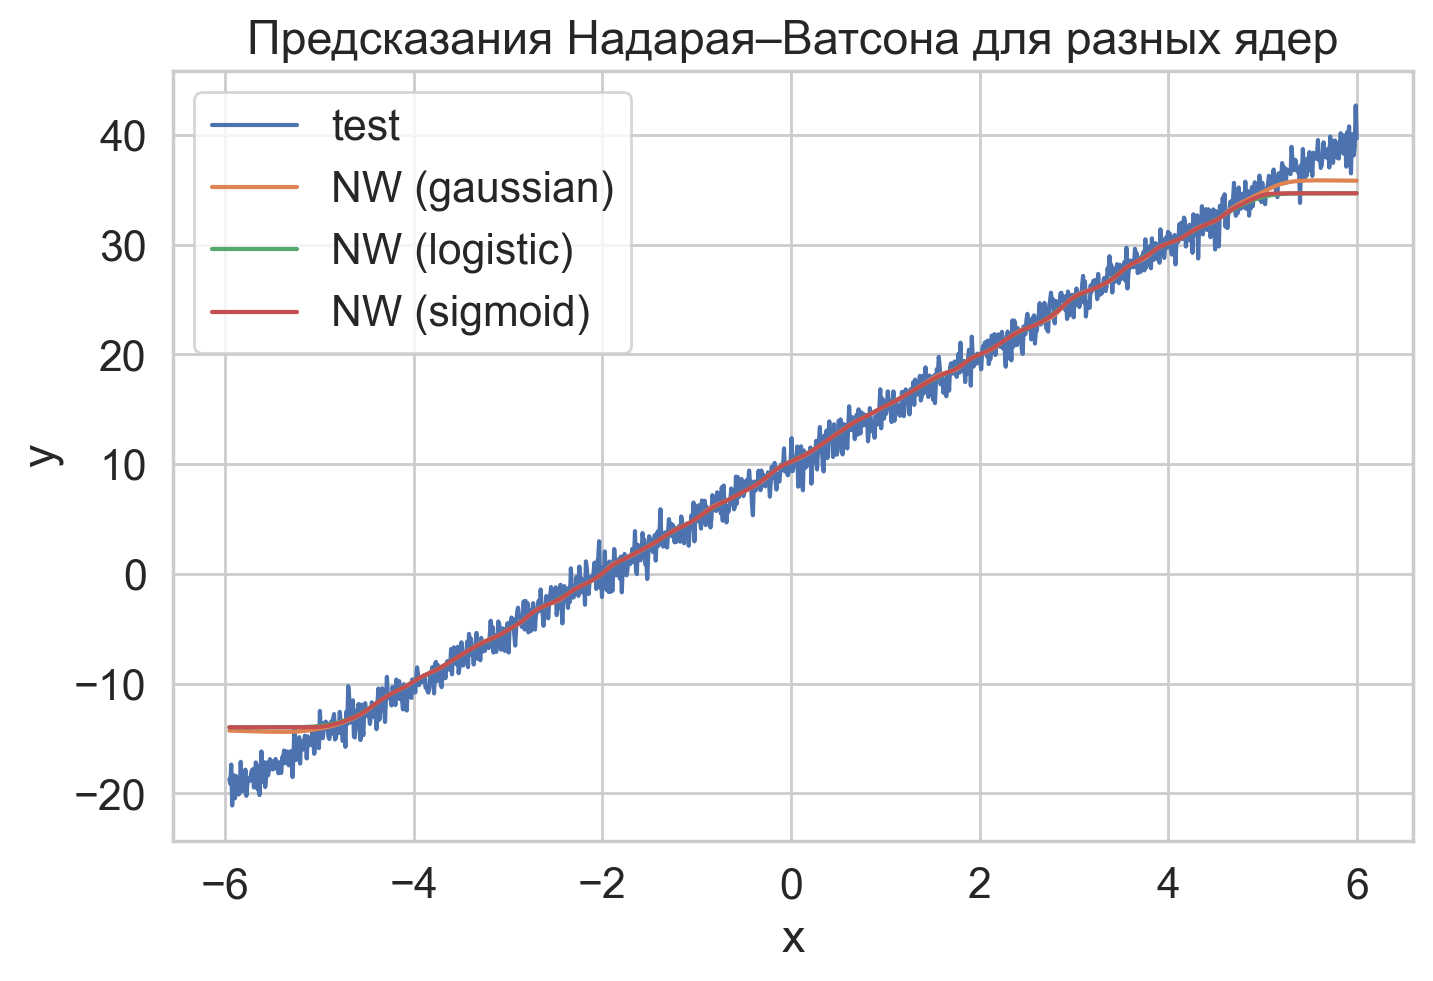

In [105]:
x_grid = np.arange(x_train.min() - 1, x_train.max() + 1, 0.01)
plt.figure(figsize=(8, 5))
eps_test = np.random.normal(loc=0.0, scale=1.0, size=x_grid.shape[0])
y_grid_test = a_true * x_grid + b_true + eps_test
plt.plot(x_grid, y_grid_test, label="test")
for name, ker in kernels.items():
    y_grid_pred = NW_predict(x_train, y_train, x_grid, h=h, kernel=ker)
    plt.plot(x_grid, y_grid_pred, label=f"NW ({name})")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Предсказания Надарая–Ватсона для разных ядер")
plt.legend()
plt.grid(True)
plt.show()

Ну ядерный метод и должен начать ошибаться на концах. в силу того, что мы хотим от ядра(симметричность) хорошее приближение работает в центре

Заметим, что мы нигде не оценивали сами параметры, но смогли решить финальную задачу -- предсказывать $y$ по $x$.

А теперь поймём, что для этого не нужна линейность.

Проделайте рассуждения выше для нелинейных зависимостей (например, $y = sin(kx) + \varepsilon, y = log(x) + \varepsilon, y = x^k + \varepsilon$ и т.д.). Постройте графики предсказаний и сравните их с истинными функциями.

0.027046724229777774
0.05590175105685211
0.05382165567988302


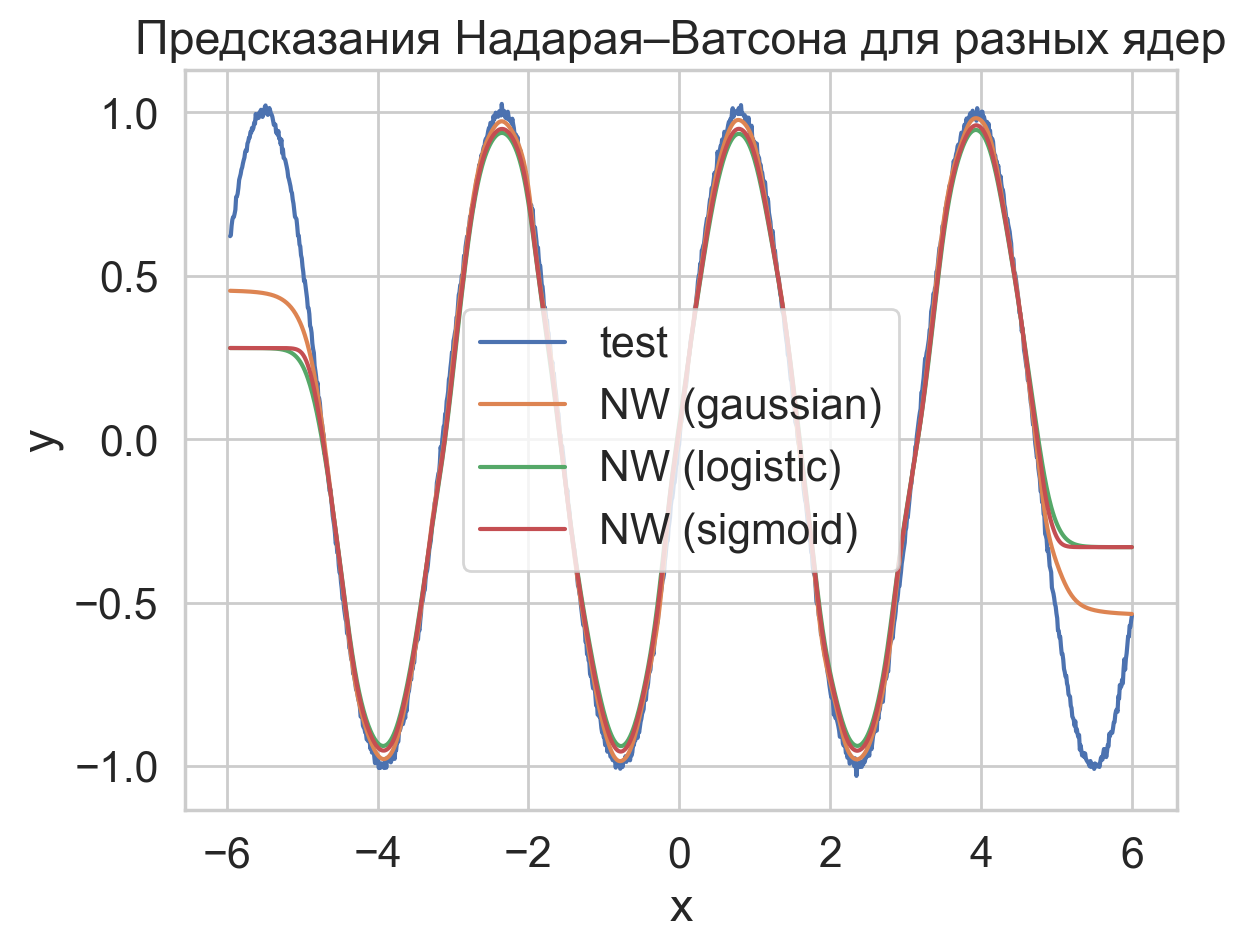

In [100]:
# y = sin(kx) + e
k = 2.0
h = 0.1
eps_test = np.random.normal(loc=0.0, scale=0.01, size=x_grid.shape[0])
eps = np.random.normal(loc=0.0, scale=0.01, size=N)
y_grid_test_sin = np.sin(k * x_grid) + eps_test
plt.plot(x_grid, y_grid_test_sin, label="test")
y_train = np.sin(k * x_train) + eps
for name, ker in kernels.items():
    y_grid_pred = NW_predict(x_train, y_train, x_grid, h=h, kernel=ker)
    plt.plot(x_grid, y_grid_pred, label=f"NW ({name})")
    print(mse(y_grid_pred, y_grid_test_sin))

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Предсказания Надарая–Ватсона для разных ядер")
plt.legend()
plt.grid(True)
plt.show()

1003027.3791961418
1208873.0678079224
1205716.2223339046


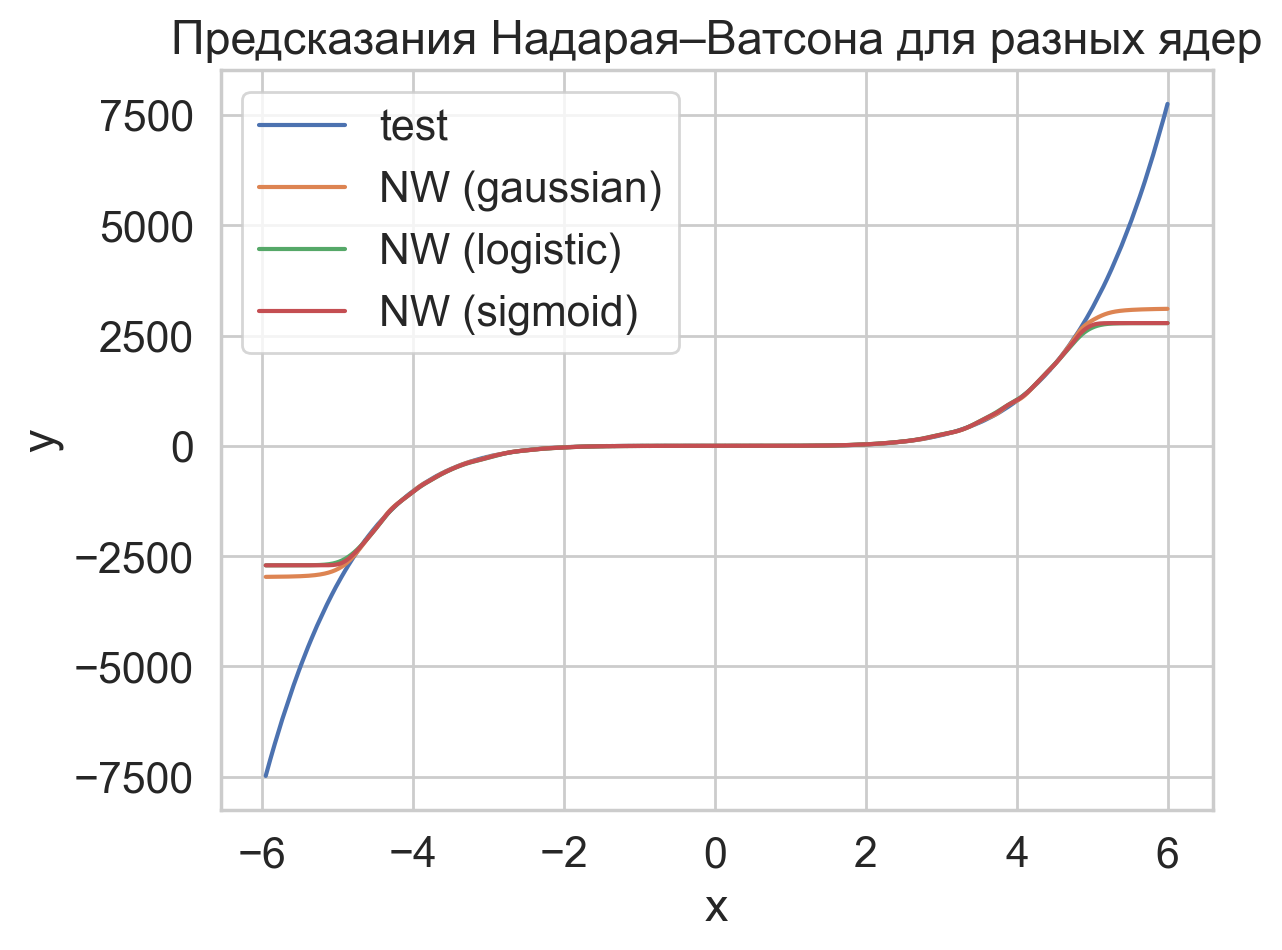

In [108]:
# y = x^k + e
k = 5
h = 0.1
eps_test = np.random.normal(loc=0.0, scale=1, size=x_grid.shape[0])
eps = np.random.normal(loc=0.0, scale=1, size=N)
y_grid_test_pow = x_grid ** k  + eps_test
plt.plot(x_grid, y_grid_test_pow, label="test")
y_train = x_train ** k + eps
for name, ker in kernels.items():
    y_grid_pred = NW_predict(x_train, y_train, x_grid, h=h, kernel=ker)
    plt.plot(x_grid, y_grid_pred, label=f"NW ({name})")
    print(mse(y_grid_pred, y_grid_test_pow))

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Предсказания Надарая–Ватсона для разных ядер")
plt.legend()
plt.grid(True)
plt.show()

**Вывод:**

Прикольно, что мы можем апроксимировать нелинейные штуки с помощью ядер. Однако mse стоит считать подальше от краев, поскольку там ядра плохо работают

Можете попробовать применить метод Надарая-Ватсона для выборки из задачи 3 и посмотреть, что получится (0 баллов)

## Задача 3. Библиотека statsmodels

*Данная задача стоит 10 баллов.*

Теперь давайте попрактикуемся в решении задач на реальных данных. Мы будем анализировать рынок недвижимости 🏘. Данные возьмем из [соревнования](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) на платформе kaggle. В отличие от соревнований нас будут интересовать зависимости в данных, а не более точные предсказания.

![](https://storage.yandexcloud.net/miptstats-public-files/pictures/housesbanner.png)

В частности мы будем смотреть на влияние различных признаков на стоимость дома (SalePrice) и проверим несколько гипотез.

In [109]:
!gdown "https://drive.google.com/uc?id=1wphoJPm4LA3-Mo_l7TRsq9uRdXkzCJqe"

Downloading...
From: https://drive.google.com/uc?id=1wphoJPm4LA3-Mo_l7TRsq9uRdXkzCJqe
To: /Users/gantulga/Downloads/train.csv
100%|████████████████████████████████████████| 461k/461k [00:00<00:00, 3.60MB/s]


In [110]:
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

In [111]:
df = pd.read_csv("train.csv")

df.fillna("NA", inplace=True)
df.head()

/var/folders/r1/1y7kwnsn7hs3y_cdn4lt2ks80000gn/T/ipykernel_4043/119077902.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("NA", inplace=True)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000


Можно заметить, что в данных присутствуют категориальные признаки, которые при этом не лишены порядка.

Вспомните курс машинного обучения. Как можно обработать категориальные признаки, чтобы регрессионная модель была осмысленна?

Ответ: воспользуемся one-hot encoder для категориальных признаков 

In [121]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

### Визуализируйте данные
Прочитайте описание датасета на Kaggle.

Сначала надо произвести выбор признаков. В рамках этой задачи будет достаточно предложить не менее 10 признаков, которые Вам просто кажутся разумными. Более честный подход -- отбор признаков -- будет рассмотрен в следующей задаче, так что, как вариант, можете сначала решить её, а потом вернуться сюда с найденными признаками.

Перед тем как начать использовать линейные модели, необходимо убедиться в том, что столбцы признаков не слишком коллинеарны. Для этого можно использовать [корреляцию Пирсона](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient#For_a_sample). Используя ``sns.heatmap``, постройте "тепловую карту" попарных корреляций признаков. Для того, чтобы увидеть числовые значения корреляций используйте ``annot=True``. Сделайте размер графика адекватным, например, ``figsize=(11, 10)``.

Какие признаки Вам кажутся самыми полезными?

выберу эти 10 признаков


OverallQual, 
GrLivArea, 
GarageArea, 
TotalBsmtSF, 
1stFlrSF, 
FullBath, 
YearBuilt, 
YearRemodAdd, 
TotRmsAbvGrd, 
Fireplaces

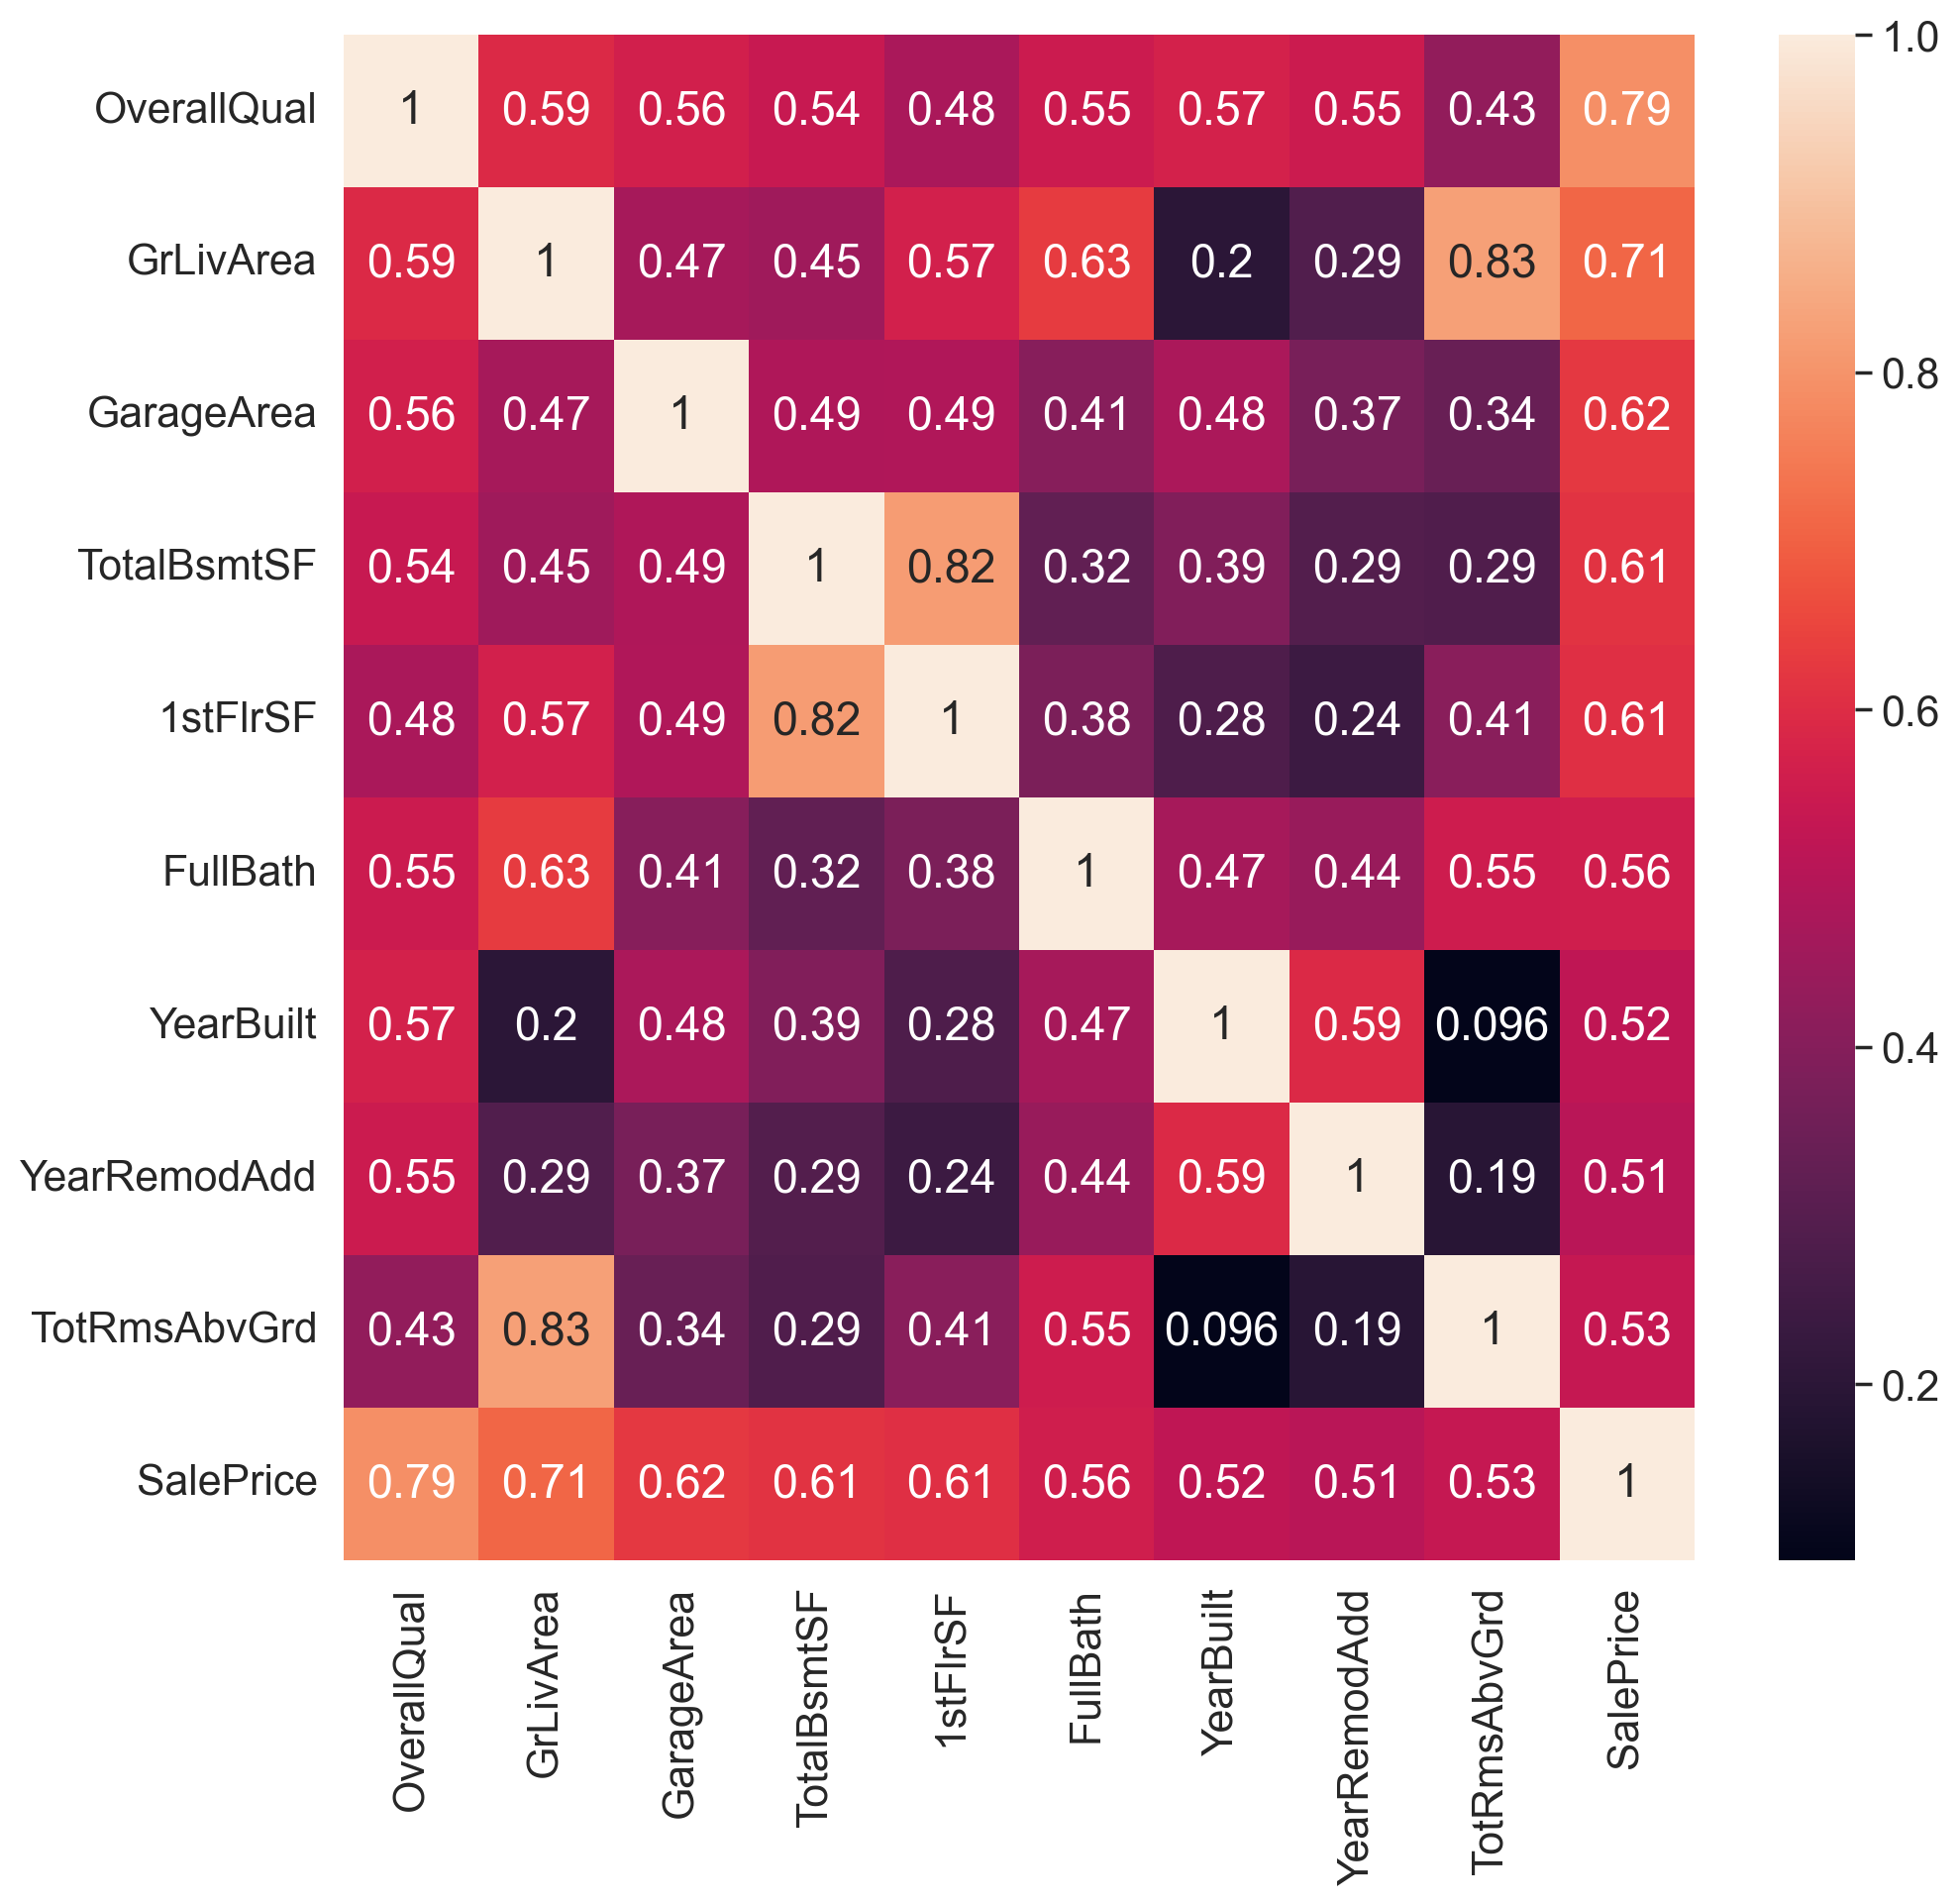

In [132]:
cols = [
    "OverallQual", 
    "GrLivArea", 
    "GarageArea", 
    "TotalBsmtSF", 
    "1stFlrSF", 
    "FullBath", 
    "YearBuilt", 
    "YearRemodAdd", 
    "TotRmsAbvGrd", 
    "SalePrice"
]

filtered_df = df[cols]

plt.figure(figsize=(11, 10))
sns.heatmap(filtered_df.corr(), annot=True)
plt.show()

Изучите карту и сделайте по ней выводы о зависимости в данных ($|r_{XY}| > 0.9$). А чем плохи зависимые признаки? Для ответа на последний вопрос напишите, чему равно аналитическое решение задачи регрессии.

**Ответ:**

В рамках нашего порога 0.9 у нас нет скоррелированных признаков. Однако есть 1stFlrSF + TotalBsmtSF = 0.82
и GrLivArea + TotRmsAbvGrd = 0.83, что по видимому скорелированно.

Почемуу это плохо - в линейной модели мы хотим, чтобы $XX^T$ была неврожденной для МНК(ну взятия производной), а с скоррелированными данными мы получаем почти вырожденную матрицу 

Удалите, если требуется, скоррелированные признаки (все, кроме одного). Удалять я пока что не буду

Давайте подробнее изучим взаимодействие признаков. Построим матрицу. На диагонали $a_{ii} = d_i$ этой матрицы построим гистограммы для $i$-го признака. На остальных позициях $a_{ij}$ будут располагаться scatterplot в осях признака $i$ по $x$ и признака $j$ по $y$. Для этого можно использовать метод из pandas ``pd.plotting.scatter_matrix``.

<Figure size 1200x1200 with 0 Axes>

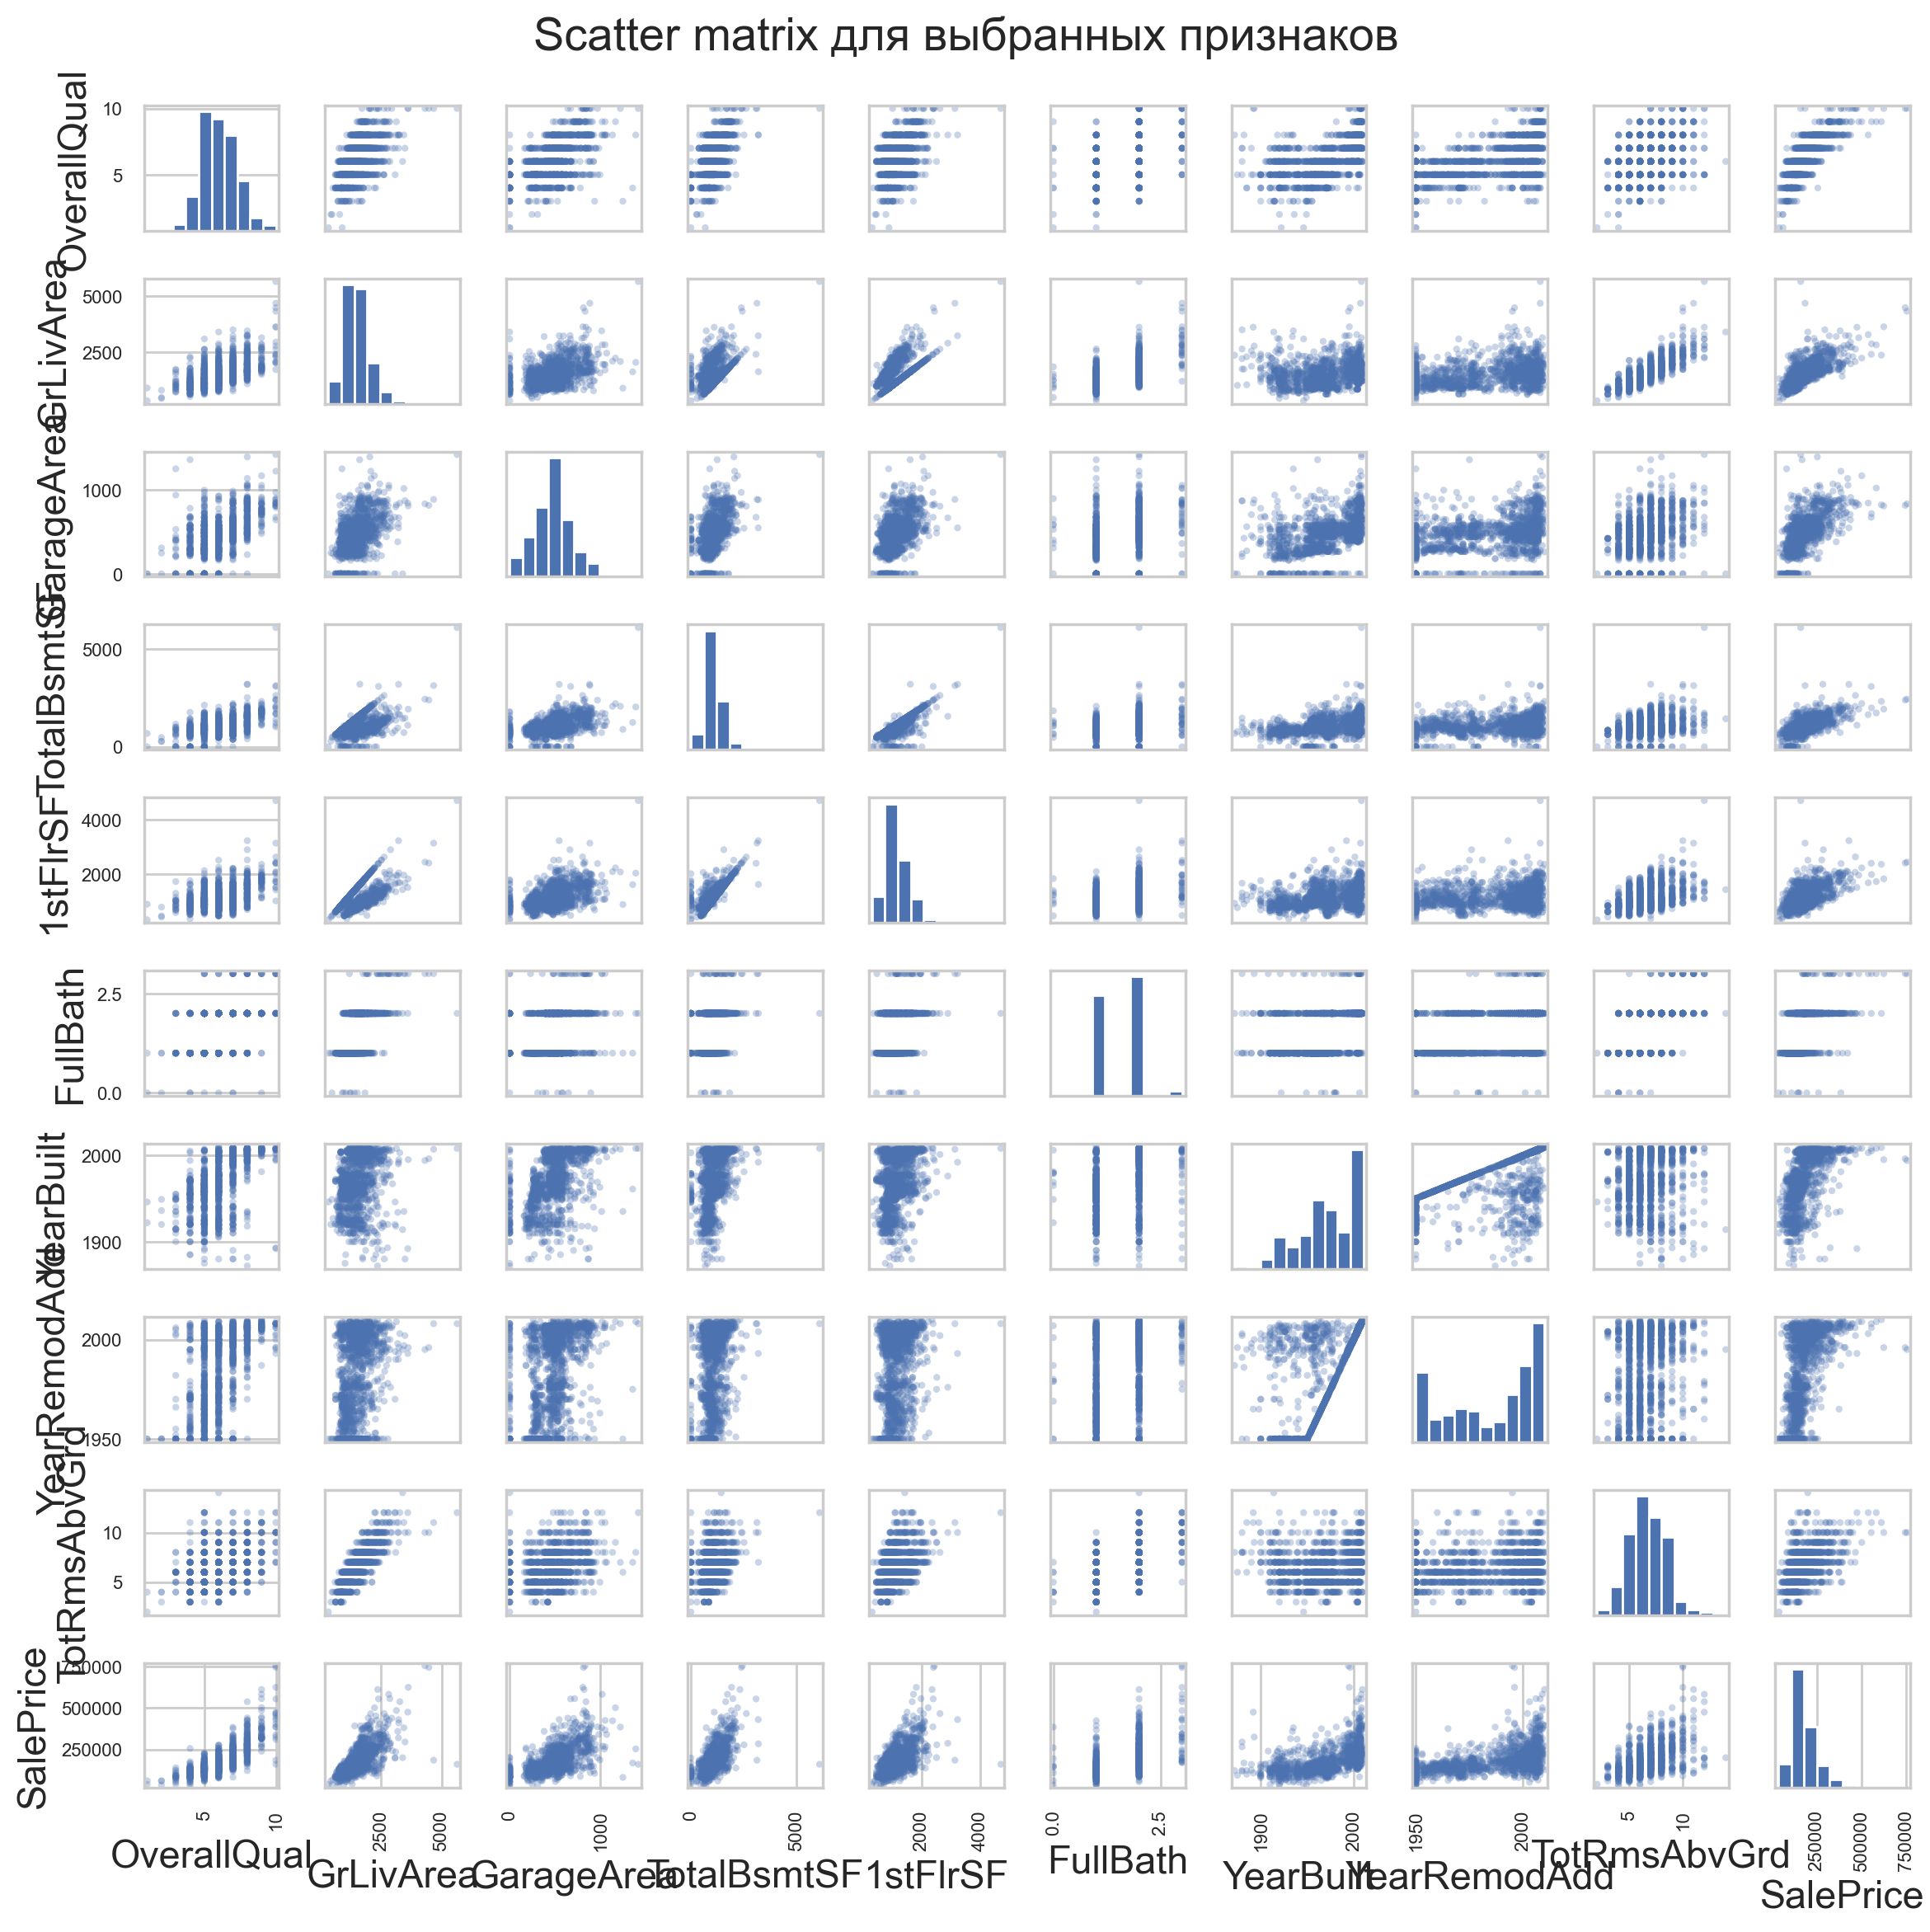

In [133]:
from pandas.plotting import scatter_matrix
plt.figure(figsize=(12, 12))
scatter_matrix(
    filtered_df,
    figsize=(12, 12),
    diagonal='hist',
    alpha=0.3,
)
plt.suptitle("Scatter matrix для выбранных признаков")
plt.tight_layout()
plt.show()

Сделайте вывод о данных. Опишите, нужна ли регуляризация и почему? Да, хорошо бы сделать регуляризацию, посольку все таки есть почти скорелированные признаки и данные шумноваты

### Как пользоваться линейными моделями

Как можно догадаться, на практике никто не пишет заново свои линейные модели. Для машинного обучения часто используют библиотеку scikit learn, для аналитики statsmodels. С первой вы познакомитесь (или уже познакомились) на курсе по ML, мы же сконцентрируемся на второй.

Итак, библиотека statsmodels состоит из множества реализованных критериев и, как ни странно, статистических моделей. Основным плюсом является то, что нам не нужно реализовывать критериии вручную, все сделано за нас (это не значит, что думать не надо!).

Начнем с линейной модели: для того, чтобы ее создать, понадобится лишь одна строка.  Как видно в ячейке ниже мы задаем формулу того, какую модель мы хотим получить. В данном случае мы хотим предсказать ``SalePrice`` по взвешенной сумме из остальных признаков.

In [134]:
filtered_df = filtered_df.rename(columns={"1stFlrSF": "FirstFlrSF"})
my_cols = [
    "OverallQual", 
    "GrLivArea", 
    "GarageArea", 
    "TotalBsmtSF", 
    "FirstFlrSF", 
    "FullBath", 
    "YearBuilt", 
    "YearRemodAdd", 
    "TotRmsAbvGrd", 
    "SalePrice"
]

formula = "SalePrice ~ " + " + ".join(my_cols[:-1])

print(formula)

SalePrice ~ OverallQual + GrLivArea + GarageArea + TotalBsmtSF + FirstFlrSF + FullBath + YearBuilt + YearRemodAdd + TotRmsAbvGrd


Теперь эту формулу мы просто передаем в модель, а так же подаем ей данные. В формуле написаны имена колонок из ``filtered_df``.

In [135]:
simple_model = smf.ols(formula, data=filtered_df)

fitted_simple_model = simple_model.fit()

print(fitted_simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     545.1
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:55:21   Log-Likelihood:                -17465.
No. Observations:                1460   AIC:                         3.495e+04
Df Residuals:                    1450   BIC:                         3.500e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -1.245e+06   1.28e+05     -9.691   

### Гетероскедастичность ошибки

**Гомоскедастичностью** называют свойство одинаковости дисперсии и независимость остатков модели.

**Гетероскедастичностью** наоборот называют свойство неодинаковости (например, с зависимостью от номера измерения)
дисперсии и независимость остатков модели.

Оценка, полученная с помощью гауссовской линейной модели, будет "хорошей" лишь при выполнении условия гомоскедастичности остатков. Для проверки на гомоскедастичность часто используют критерий Бройша — Пагана. Мы не будем вдаваться в детали и доказательство того, что критерий валидный и работает правильно. Итак, критерий Бройша — Пагана проверяет нулевую гипотезу о гомоскедастичности распределения данных против альтернативы, то есть гетероскедастичности. Если нулевая гипотеза отвергается, то можно сказать, что данные распределены ГЕТЕРОскедастично. Мы этого не хотим.

Критерий реализован с помощью функции ``sms.diagnostic.het_breuschpagan``. Документацию можно найти [здесь](https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.het_breuschpagan.html).

Остатки модели можно из поля ``fitted_simple_model.resid``, а параметры из ``fitted_simple_model.model.exog``.

Нас интересует p-value для множителя Лагранжа.

В ячейке ниже получите уровень достигаемой значимости для критерия Бройша — Пагана.

In [136]:
p_val_het = sms.diagnostic.het_breuschpagan(resid=fitted_simple_model.resid,
                                            exog_het=fitted_simple_model.model.exog)[1]

print(f"p-value simple: {p_val_het}")

p-value simple: 4.4399836827158775e-82


Отвергается ли гипотеза о гомоскедастичности остатков? Что это означает?

**Ответ:** Да, гипотеза отвергается. Это значит, что ошибка гетероскедатична 

В случаях, когда распределение остатков не является гомоскедастичным, оценка по-прежнему остается несмещенной, однако стоит сделать некоторую поправку, на более высокую дисперсию. Поэтому значения F-критериев и t-критериев для коэффициентов стоит пересмотреть. Для таких случаев существует достаточно много различных поправок, одно из семейств таких поправок называется поправки Уайта на гетероскедастичность. Ниже мы попробуем использовать одну из поправок.

Для этого, в ячейке ниже, обучите линейную модель, но на этот раз передайте в метод ``.fit`` аргумент ``cov_type="HC1"``.

Получите summary для такой модели.

In [137]:
new_model = simple_model.fit(cov_type="HC1")
print(new_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     265.6
Date:                Sat, 29 Nov 2025   Prob (F-statistic):          3.62e-299
Time:                        14:05:18   Log-Likelihood:                -17465.
No. Observations:                1460   AIC:                         3.495e+04
Df Residuals:                    1450   BIC:                         3.500e+04
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -1.245e+06   1.09e+05    -11.403   

Проанализируйте результаты. Как изменились показатели из таблицы?

**Ответ:**  признаки TotalBsmtSF и FullBath перестали быть значимыми. Еще F-статистика уменьшилась в два раза

### Преобразование целевого признака

Посмотрим на распределение остатков линейной модели с целевой величиной `SalePrice`. Постройте QQ-plot для нормального распределения и гистограмму остатков.

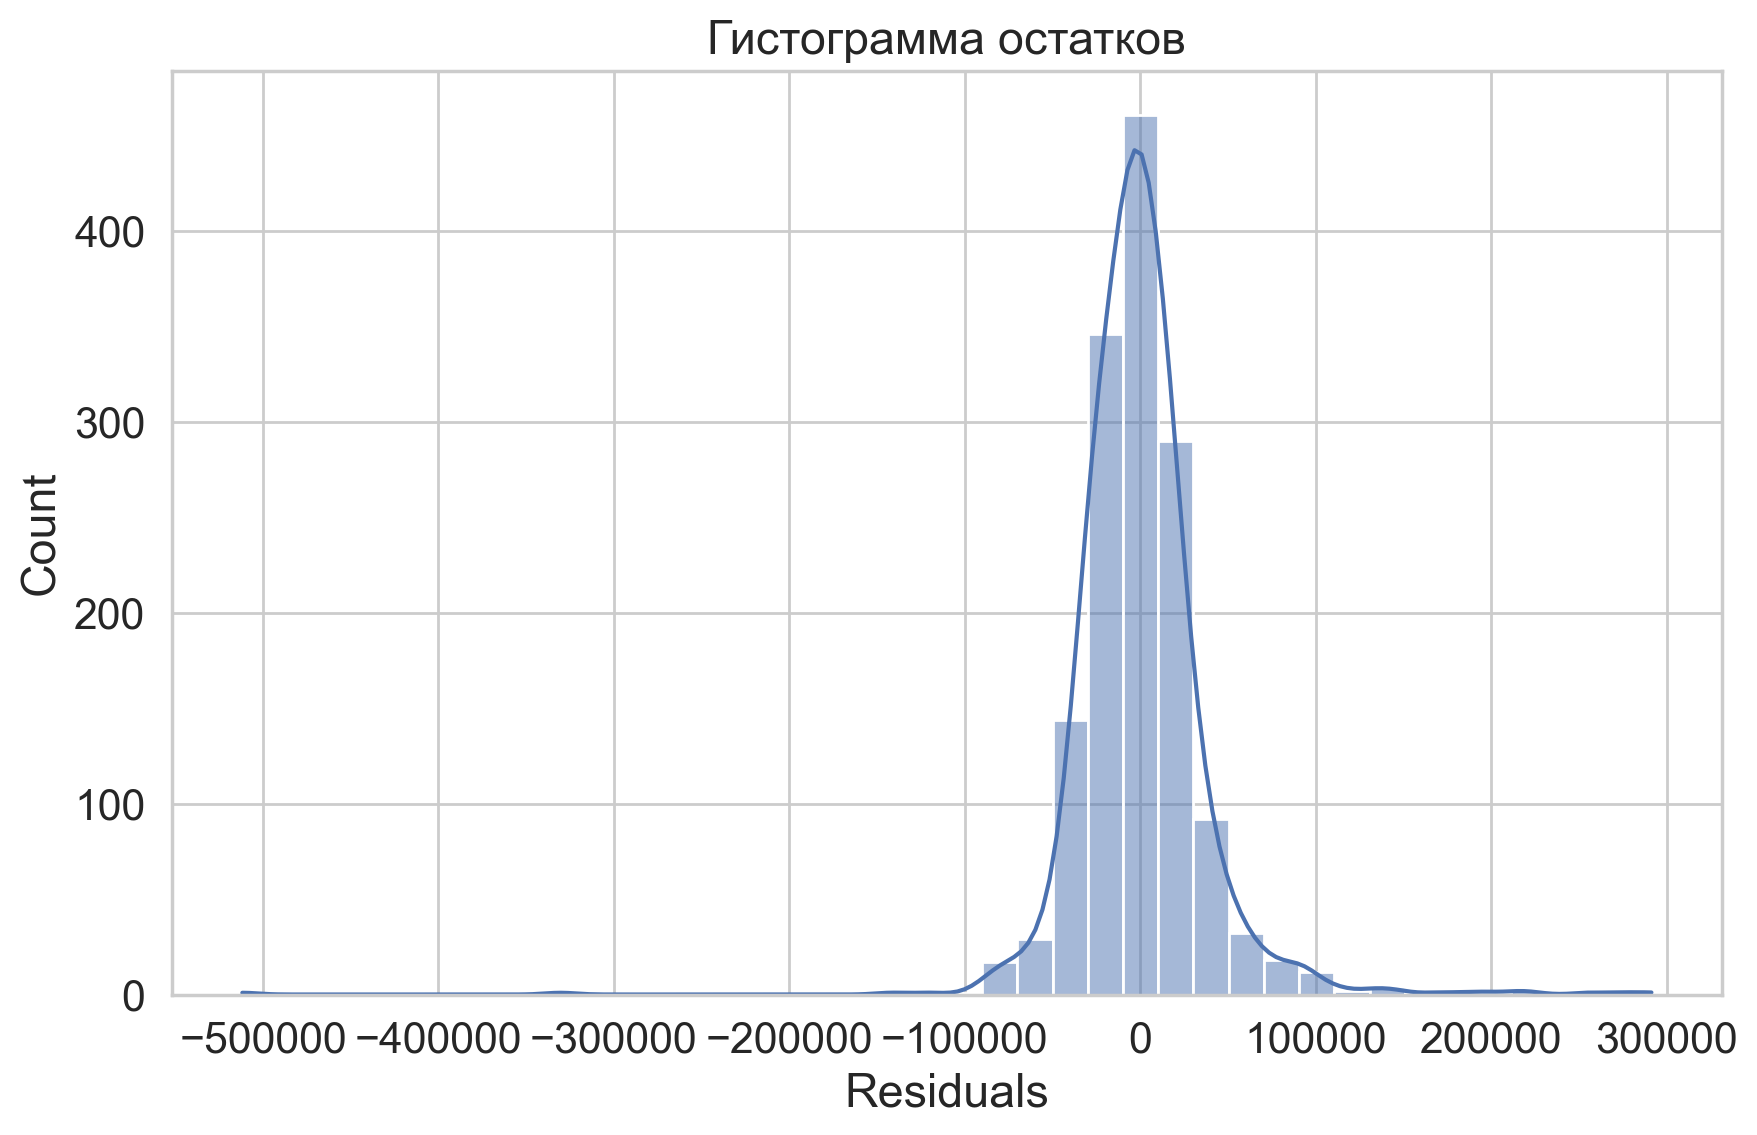

<Figure size 800x800 with 0 Axes>

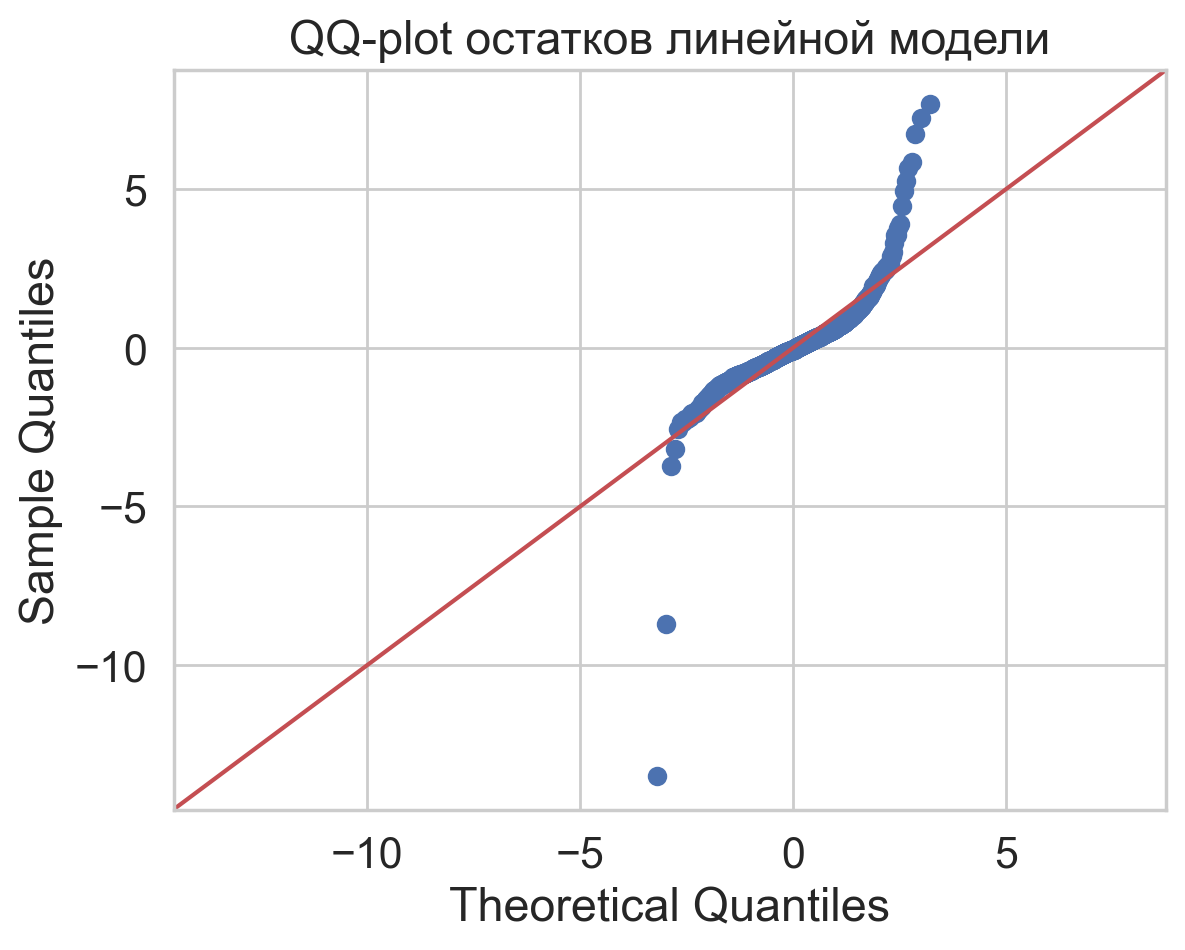

In [149]:
import statsmodels.api as sm
resid = fitted_simple_model.resid

plt.figure(figsize=(10, 6))
sns.histplot(resid, kde=True, bins=40)
plt.title("Гистограмма остатков")
plt.xlabel("Residuals")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
sm.qqplot(resid, line="45", fit=True)
plt.title("QQ-plot остатков линейной модели")
plt.grid(True)
plt.show()

Как вы считаете, можно ли сказать, что распределение остатков нормально?

**Ответ:** прям сильно видно, что остатки распределены не нормально - хвосты супертяжелые

Давайте обучим модель предсказывать не SalePrice, а ее логарифм. Для этого снова обновим формулу для модели. Прелесть формул в том, что в них можно использовать операции из numpy. Например, можно искать зависимость не от ``PoolArea``, а от ее квадрата, то есть ``np.power(PoolArea, 2)``. Достаточно просто добавить в формулу ..." + np.power(PoolArea, 2)" --- и все заработает!

В ячейке ниже обучите модель предсказывать логарифм SalePrice. Получите summary этой модели.

In [144]:
formula_log = "np.log(SalePrice) ~ " + " + ".join(my_cols[:-1])

log_model = smf.ols(formula_log, data=filtered_df)
fitted_log_model = log_model.fit()

print(fitted_log_model.summary())

                            OLS Regression Results                            
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     720.0
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:16:54   Log-Likelihood:                 508.96
No. Observations:                1460   AIC:                            -997.9
Df Residuals:                    1450   BIC:                            -945.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.2503      0.578      3.892   

Как изменился коэффициент R^2? Модель лучше стала понимать данные?

**Ответ:** R2 вырос с 0.77 до 0.82. Значит связь с логарифмом цены более линейная чем просто с ценой - модель стала лучше чувствовать зависомость

Постройте графики остатков, аналогичные тем, что встретились нам на две ячейки выше (QQ-plot и гистограмму остатков). Но на этот раз для модели, предсказывающией логарифм.

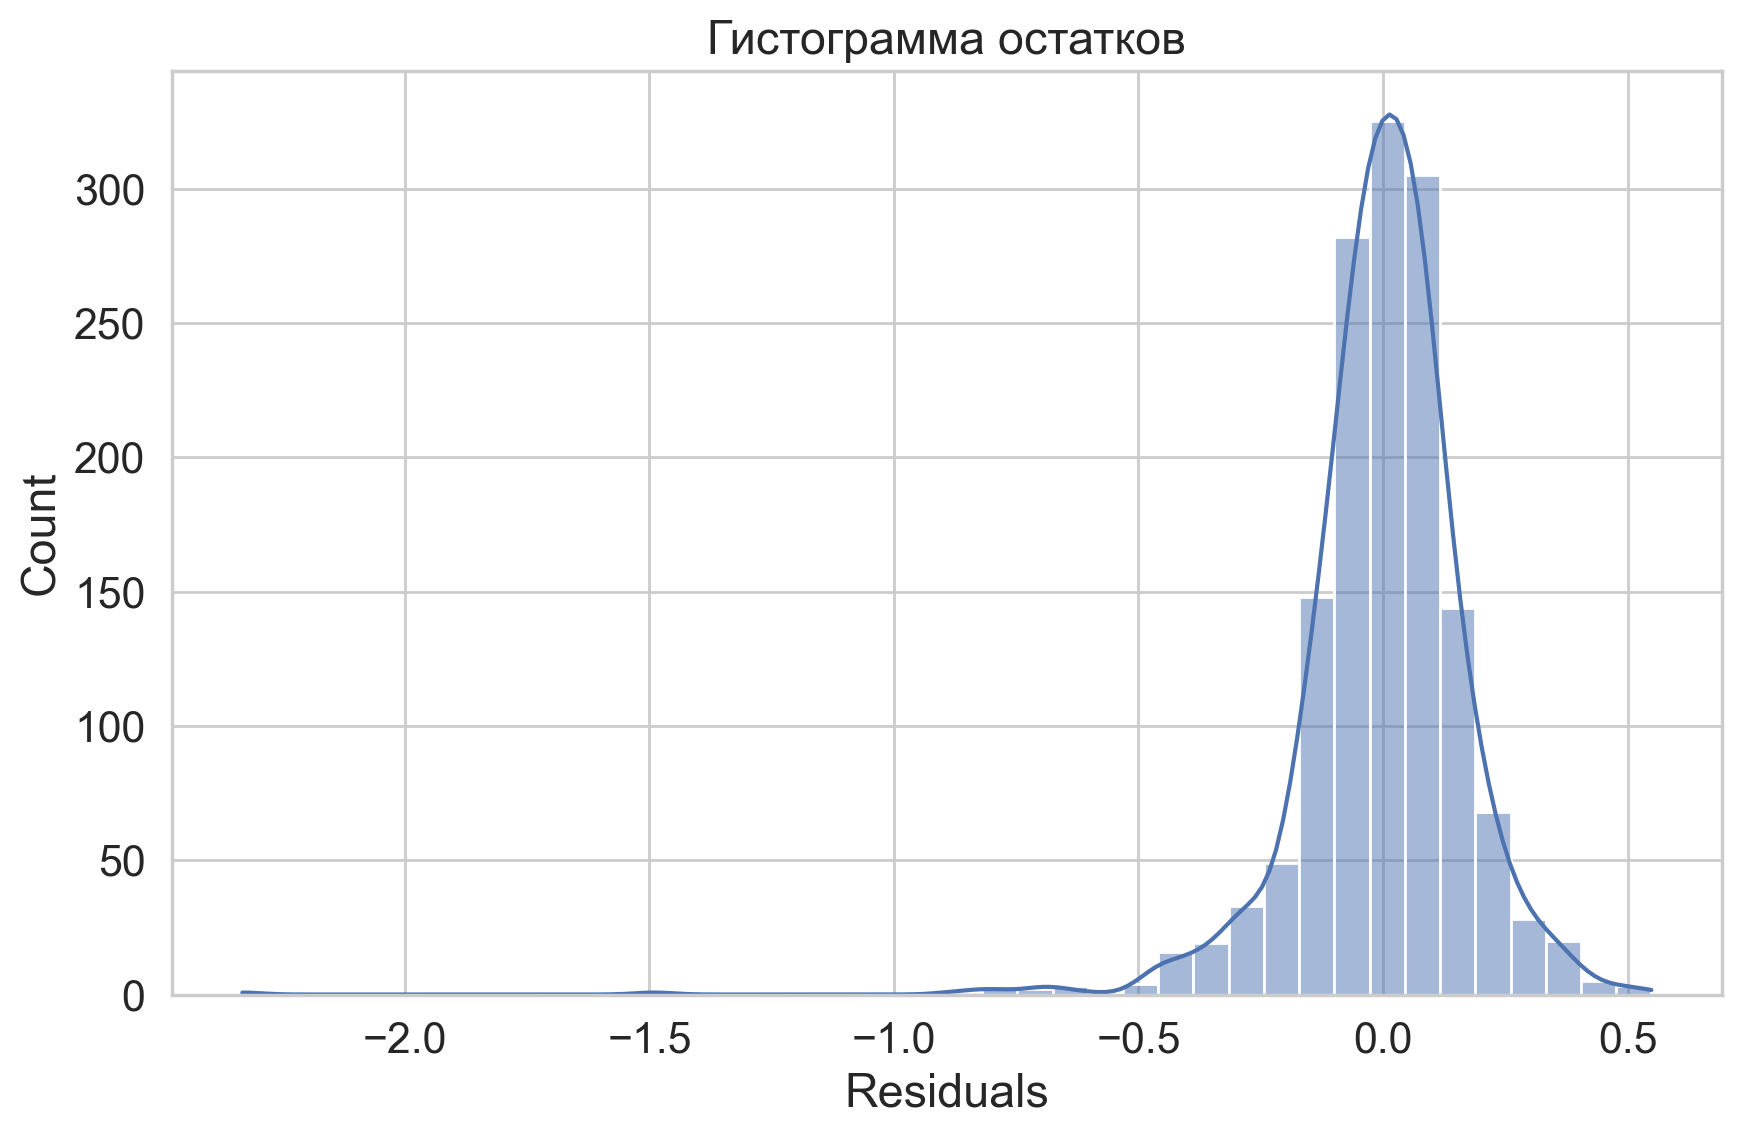

<Figure size 800x800 with 0 Axes>

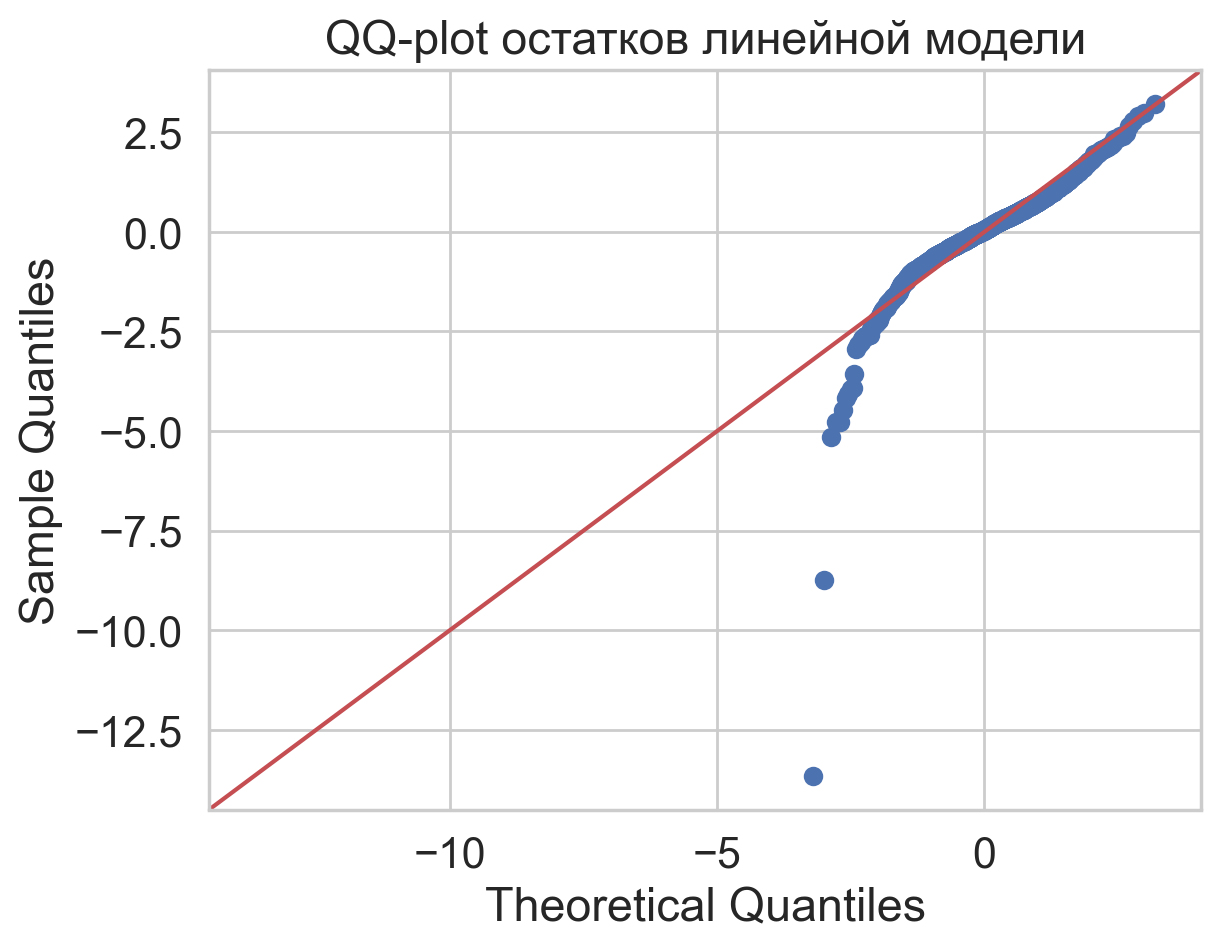

In [147]:
import statsmodels.api as sm
resid = fitted_log_model.resid

plt.figure(figsize=(10, 6))
sns.histplot(resid, kde=True, bins=40)
plt.title("Гистограмма остатков")
plt.xlabel("Residuals")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
sm.qqplot(resid, line="45", fit=True)
plt.title("QQ-plot остатков линейной модели")
plt.grid(True)
plt.show()

Ну можно сказать, что остатки теперь более нормальные - однако выбросы никуда не ушли и нижний хвост тоже куда-то уплыл

Как вы считаете, стоит ли предсказывать логарифм от цены? В каких случаях это полезно?

**Ответ:**

Это полезно наверное, когда мы ожидаем больше процентных изменений нежели абсолютынх. К тому же стоит посмотреть на распределение просто цен - если они скошены относительно нормального распределения, то стоит отлогорифмировать. Возможно, еще гетероскедатичность тоже тригггер для логарфмирования

## Задача 4. Отбор признаков

*Данная задача стоит 10 баллов.*

**Дисклеймер:** задача будет засчитана, если задача 3 этого задания сделана до пункта "Гетеросгедантичность ошибки" включительно!

В прошлой задаче мы строили линейные модели на основании признаков, выбранных по текстовому описанию. Конечно, так делать не очень хорошо, а к выбору признаков нужно подойти с умом. В этом задании мы проведём исследование о том, какие признаки оказываются более или менее информативными. Для построения регрессионных моделей можно пользоваться библиотекой statsmodels.

1.  Добавьте ещё 5 осмысленных признаков в модель. В каждом пункте мы будем очередным способом выбирать 5 и 10 лучших признаков.

2. Используя критерий Стьюдента проверьте гипотезу о бесполезности для каждого признака (для этого надо запустить модель один раз, а не 15 раз). Если вдруг эта гипотеза не отвергается, удалите признак и замените его другим. Обратите внимание, что если таких признаков 2, то, чтобы удалить их вместе, нужно либо применить критерий Фишера, либо после удаления первого признака применить снова критерий Стьюдента. Ответьте на вопрос "зачем"?

2. Самым простым показателем качества модели является $R^2$. Из summary возьмите $R^2$ для всей модели и для каждого признака изучите, как он меняется для модели без этого признака. Пожалуйста, не выводите на экран 15 таблиц.

Как изменяется $R^2$? Что известно теоретически о том, как он должен вести себя при удалении признака? Отсортируйте признаки по "вкладу" в $R^2$. Сделайте вывод о том, насколько разумным получился отбор.

3. Для "честного" сравнения моделей с разным числом признаков коэффициент $R^2$ корректируют. Сравните скорректированный $R^2$ для модели с всеми признаками и 15ти моделей без одного признака. Какие модели оказались лучше? Отсортируйте снова признаки по важности и сделайте вывод.

4. *Информационный подход к отбору признаков*. Для 1+15 моделей из пункта выше рассчитайте коэффициенты AIC и BIC. Сравните модели по ним и отсортируйте признаки по важности. Одинаковый ли порядок? Чему больше доверия: $R^2$ с поправкой или информационным коэффициентам?

5. *Оптимизационный подход к отбору признаков*. В пакете sklearn найдите lasso-регрессию и реализуйте её с 5 разными коэффициентами регуляризации, так чтобы в каждом случае обнулились коэффициенты у разного числа признаков. Те признаки, который обнуляются раньше мы будем считать более бесполезными, так как модель жертвует ими в первую очередь. Отсортируйте признаки согласно важности в терминах лассо-регрессии и сравните порядок с предыдущими.

6. Бонусный пункт (+5 баллов). *Теоретико-игровой подход к отбору признаков*. Посмотрите лекцию, сходите на семинар по теории игр или любым другим способом узнайте о том, что такое вектор Шепли. Отберите от 5 до 15 (в зависимости от мощности Вашего ПК) признаков-кандидатов и разыграйте между ними игру: для каждого подмножества признаков обучите модель и посмотрите как много $R^2$ (или любого другого коэффициента) они зарабатывают. Согласно вектору Шепли разделите "награду" $R^2$ модели из всех признаков по каждому признаку. Отсортируйте признаки согласно их "заработку" и сравните порядок с предыдущими.

Предложите итоговый порядок признаков по важности, 5 и 10 самых важных признаков. Какому методу Вы доверились? Подумайте о том, как лучше поступить в случае мультикорреляции (наличии зависимости между признаками): регуляризовать или отобрать независимое подмножество фичей?

**Вывод:**

## Задача 5. Дисперсионный анализ

*Данная задача стоит 10 баллов.*

На практике часто возникает необходимость сравнить средние значения в трёх и более группах. Наивный подход, заключающийся в попарном применении t-критерия, приводит к проблеме множественной проверки гипотез и увеличению доли ошибки I рода. Корректным методом для такой задачи является дисперсионный анализ (ANOVA) (ANalysis Of VAriance).

[comment]: <> (Поздравляю, ты нашёл пасхалку! Сообщи об этом в чат 4-ого практикума. Первому сообщившему до дедлайна полагается вкусная шоколадка.)


Основная идея ANOVA заключается в сравнении разницы данных между группами с разницой внутри групп. Если разница между группами значительно превышает разницу внутри них, мы заключаем, что средние значения в группах различаются.

### 1. Классический однофакторный ANOVA

Пусть у нас есть $k$ независимых выборок (групп) $X_{11} \ldots X_{1 n_1}, X_{2, 1}, \ldots, X_{k, n_k}$. Формально, модель однофакторного ANOVA предполагает, что каждое наблюдение $X_{ij}$ ($j$-е наблюдение в $i$-й группе) можно представить в виде:
$$
X_{ij} = \mu + \alpha_i + \varepsilon_{ij}
$$
где:
-   $\mu$ - общее среднее для всех наблюдений.
-   $\alpha_i$ - эффект, связанный с принадлежностью к группе $i$.
-   $\varepsilon_{ij}$ - независимые ошибки (шум), распределённые как $\mathcal{N}(0, \sigma^2)$.

И есть такие допущения модели:
1.  Независимость ошибок $\varepsilon_{ij}$.
2.  Нормальность их распределения: $\varepsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$.
3.  Гомоскедантичность: равенство дисперсий во всех группах ($\sigma_1 = \ldots = \sigma_k = \sigma$).


Нулевая гипотеза о равенстве средних во всех группах $$H_0 : \mu_1 = \mu_2 = \dots = \mu_k$$
в терминах этой модели эквивалентна гипотезе об отсутствии групповых эффектов: $$H_0 : \alpha_1 = \alpha_2 = \dots = \alpha_k = 0$$

Для проверки этой гипотезы общая изменчивость данных (SST) раскладывается на межгрупповую (SSB) и внутригрупповую (SSW):
$$
\underbrace{\sum_{i=1}^{k} \sum_{j=1}^{n_i} (X_{ij} - \overline{\overline{X}})^2}_{\mathrm{SST} \text{ (Total Sum of Squares)}} = \underbrace{\sum_{i=1}^{k} n_i (\overline{X}_i - \overline{\overline{X}})^2}_{\mathrm{SSB} \text{ (Sum of Squares Between)}} + \underbrace{\sum_{i=1}^{k} \sum_{j=1}^{n_i} (X_{ij} - \overline{X}_i)^2}_{\mathrm{SSW} \text{ (Sum of Squares Within)}}
$$
Далее вычисляются такие штуки:
$$
\mathrm{MSB} = \frac{\mathrm{SSB}}{k-1}, \quad \mathrm{MSW} = \frac{\mathrm{SSW}}{N-k}
$$
где $N = \sum_{i=1}^k n_i$.

Их отношение даёт F-статистику, которая при верности $H_0$ имеет распределение Фишера:
$$
F = \frac{\mathrm{MSB}}{\mathrm{MSW}} \sim F_{k-1, N-k}
$$


Проверим корректность классического ANOVA. Сгенерируйте 10000 наборов из 4-х нормальных выборок, находясь в рамках нулевой гипотезы (все $\alpha_i = 0$, например, все выборки из $\mathcal{N}(0, 1)$). Размеры выборок возьмите равными 30.

In [ ]:
# Ваш код здесь

Для всех наборов данных посчитайте p-value с помощью готовой реализации, например, [`scipy.stats.f_oneway`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html).

In [ ]:
# Ваш код здесь

Визуализируйте распределение полученных p-value. Оцените вероятность ошибки I рода для уровня значимости $\alpha=0.05$ и постройте для неё 95%-й доверительный интервал. Сделайте вывод о корректности критерия в данных условиях.

In [ ]:
# Ваш код здесь

**Вывод:**



### 2. А что если допущения нарушаются

Классический ANOVA требует выполнения ряда строгих условий. Проверим, что происходит, когда они нарушаются, и рассмотрим альтернативы.


**A. Нарушение нормальности**

Когда допущение о нормальности нарушено, особенно для малых выборок, используют непараметрический аналог - критерий Краскела-Уоллиса. По сути это некоторая "ANOVA на рангах", поскольку его идея заключается в применении логики дисперсионного анализа не к исходным данным, а к их рангам.

В наиболее общем виде критерий Краскела-Уоллиса проверяет нулевую гипотезу о том, что все $k$ выборок взяты из одного и того же распределения. Если обозначить через $F_i(x)$ функцию распределения (CDF) для $i$-й группы, то гипотезу можно записать так:
$$
H_0: F_1(x) = F_2(x) = \dots = F_k(x)
$$

Если мы предполагаем, что формы и масштабы (дисперсии) распределений для всех групп одинаковы, они могут отличаться только сдвигом. В этом случае модель для данных можно записать как:
$$
F_i(x) = F(x - m_i)
$$
где $F$ — функция распределения общей формы, а $m_i$ — медиана (или любой другой параметр сдвига) для $i$-й группы. При таком допущении общая нулевая гипотеза $H_0: F_1 = \ldots = F_k$ становится эквивалентна более простой и понятной гипотезе о равенстве медиан:
$$
H_0: m_1 = m_2 = \dots = m_k
$$

**Непосредственно критерий**

Процедура такова:
1.  Все наблюдения из всех $k$ групп объединяются в один ряд.
2.  Этому объединённому ряду присваиваются ранги от 1 до $N$ (где $N$ — общее число наблюдений).
3.  Затем вычисляется статистика, которая, по сути, повторяет идею F-статистики ANOVA.

Вспомним, что F-статистика сравнивает межгрупповую дисперсию с внутригрупповой. Аналогично, статистика Краскела-Уоллиса $H$ основана на межгрупповой сумме квадратов отклонений для рангов ($SSB_R$). Если обозначить $R_{ij}$ как ранг наблюдения $X_{ij}$ в общей выборке, $\bar{R}_i$ как средний ранг в группе $i$, а $\overline{\overline{R}} = (N+1)/2$ как общий средний ранг, то:
$$
SSB_R = \sum_{i=1}^k n_i (\bar{R}_i - \overline{\overline{R}})^2
$$
Общая сумма квадратов для рангов ($SST_R$) является фиксированной величиной для заданного $N$:
$$
SST_R = \sum_{i=1}^k \sum_{j=1}^{n_i} (R_{ij} - \overline{\overline{R}})^2 = \frac{N(N^2-1)}{12}
$$
Тогда статистика $H$ определяется как отношение межгрупповой изменчивости рангов к общей, нормированное на $(N-1)$:
$$
H = (N-1)\frac{SSB_R}{SST_R}
$$
После алгебраических преобразований эта формула приводится к более известному и удобному для вычислений виду, использующему суммы рангов в группах ($R_i = \sum_{j=1}^{n_i} R_{ij}$):
$$
H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)
$$
При верности нулевой гипотезы статистика $H$ асимптотически имеет распределение $\chi^2_{k-1}$

Сгенерируйте выборки (4 группы по 30 наблюдений) из следующих распределений, не забыв их отнормировать так, чтобы теоретические средние и дисперсии были одинаковы:
*   Все выборки из распределения Лапласа.
*   Все выборки из распределения Стьюдента $T_3$.
*   Две выборки из $\mathcal{N}(0, 1)$, одна из $\mathrm{Beta}(5, 1)$, одна из $\mathrm{U}[-1, 1]$.

Для каждого случая примените и классический ANOVA, и критерий Краскела-Уоллиса ([`scipy.stats.kruskal`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html)). Визуализируйте распределения p-value и оцените ошибку I рода для обоих критериев. (Пометка, на самом деле ANOVA является довольно робастной относительно нарушения условия нормальности, поэтому вероятно получится, что с p-value будет ок, особенно для симметричных распределений)

In [ ]:
# Ваш код здесь

Вывод:

**Б. Нарушение гомоскедантичности**

Теперь сгенерируйте 4 группы (по 50 наблюдений) из нормальных распределений с равными средними, но разными дисперсиями: $\mathcal{N}(0, 1)$, $\mathcal{N}(0, 4)$, $\mathcal{N}(0, 9)$, $\mathcal{N}(0, 16)$. Примените к ним классический ANOVA и оцените ошибку I рода.

In [ ]:
# Ваш код здесь

Для случая гетероскедантичности существует ANOVA Уэлча. Его готовой реализации в `scipy.stats` нет, но он есть в `pingouin.welch_anova`.

Примените ANOVA Уэлча к данным с разными дисперсиями. Оцените ошибку I рода.

In [ ]:
# Ваш код здесь

Вывод:

### 3. Бонусный пункт (+5 баллов) ANOVA для повторных измерений

В предыдущих пунктах мы исходили из допущения о независимости выборок. Однако во многих экспериментальных планах это условие нарушается намеренно. Классический пример — измерение некоторого показателя у одних и тех же испытуемых в нескольких разных условиях или в разное время (например, до, во время и после лечения). Такой дизайн называется дизайном с повторными измерениями.

Применение стандартного ANOVA к таким данным некорректно, из-за допущения о независимости наблюдений. Оценка одного и того же человека в разное время, очевидно, не является независимой: если у человека в принципе высокий уровень тревожности, его показатели, скорее всего, будут выше среднего во всех условиях. Эта систематическая изменчивость, связанная с индивидуальными различиями между испытуемыми, не является случайным шумом.

Приводит это всё к двум проблемам:
1. Знаменатель F-статистики становится завышенным.
2. Из-за большого знаменателя F-статистика становится меньше, и критерий реже обнаруживает реальные различия между условиями (ну или ещё можно сказать что он резко теряет мощность вплоть до бессмысленности применения).

Модель ANOVA для повторных измерений выглядит так:
$$
X_{ij} = \mu + \pi_j + \tau_i + \varepsilon_{ij}
$$
где:
*   $X_{ij}$ — наблюдение для $j$-го испытуемого ($j=1, \dots, n$) в $i$-м условии ($i=1, \dots, k$).
*   $\mu$ — общее среднее.
*   $\pi_j$ — случайный эффект, связанный с $j$-м испытуемым (его отклонение от общего среднего). Это и есть учет индивидуальных различий.
*   $\tau_i$ — фиксированный эффект, связанный с $i$-м условием (то, что мы хотим проверить).
*   $\varepsilon_{ij}$ — случайная ошибка (взаимодействие испытуемого и условия).

Также, разумеется, данные разных испытуемых должны быть независимы друг от друга (то есть зависимость мы допускаем только в рамках замера испытуемого $i$, $\forall i$)

Нулевая гипотеза заключается в отсутствии эффекта условия:

$$H_0: \tau_1 = \tau_2 = \dots = \tau_k = 0$$

F-статистика строится как отношение среднего квадрата для условия к среднему квадрату ошибки:
$$
F = \frac{SS_{\text{condition}} / (k-1)}{SS_{\text{error}} / ((n-1)(k-1))}
$$
Обратите внимание, что в знаменателе теперь стоит не общая внутригрупповая дисперсия. Полностью разложение дисперсии выглядит так:

$$
SS_{\text{total}} = \sum_{i=1}^{k} \sum_{j=1}^{n} (X_{ij} - \bar{X}_{..})^2
$$

$$
SS_{\text{subjects}} = k \sum_{j=1}^{n} (\bar{X}_{.j} - \bar{X}_{..})^2
$$

$$
SS_{\text{condition}} = n \sum_{i=1}^{k} (\bar{X}_{i.} - \bar{X}_{..})^2
$$

$$
SS_{\text{error}} = SS_{\text{total}} - SS_{\text{subjects}} - SS_{\text{condition}}
$$

**Допущение о сферичности**

Помимо нормальности, rANOVA имеет важное дополнительное допущение - сферичность. Оно означает, что дисперсии разностей между всеми возможными парами условий должны быть примерно одинаковы. Нарушение этого допущения (что случается довольно часто) завышает вероятность ошибки I рода. Для борьбы с этим применяют поправки (например, Гринхауса-Гейссера), которые корректируют степени свободы.

При верности нулевой гипотезы и выполнении допущений (включая сферичность), эта статистика имеет распределение Фишера $F_{k-1, (n-1)(k-1)}$





**А что если опять нет нормальности**

Тогда используется критерий Фридмана. По сути он является некоторым развитием критерия Краскела-Уоллиса для зависимых выборок.

1.  Для каждого испытуемого отдельно его наблюдения в разных условиях ранжируются (например, от 1 до $k$).
2.  Далее вычисляются суммы рангов для каждого условия.

Статистика Фридмана вычисляется по формуле:
$$
F_r = \left[ \frac{12}{nk(k+1)} \sum_{i=1}^{k} R_i^2 \right] - 3n(k+1)
$$
где $n$ — число испытуемых (блоков), $k$ — число условий, а $R_i$ — сумма рангов для $i$-го условия по всем испытуемым.

При верности $H_0$ и достаточно большом числе испытуемых ($n$), статистика Фридмана $F_r$ асимптотически имеет распределение $\chi^2_{k-1}$

Смоделируем эксперимент. Пусть у нас есть 50 испытуемых. Для каждого испытуемого сгенерируем его "базовый" уровень эффекта $b_j \sim \mathcal{N}(0, 5^2)$. Затем измерим показатель для каждого испытуемого в трёх условиях. При верности $H_0$, эффект условия равен нулю. Таким образом, измерения будут:
$X_{1j} = b_j + \varepsilon_{1j}$, $X_{2j} = b_j + \varepsilon_{2j}$, $X_{3j} = b_j + \varepsilon_{3j}$, где $\varepsilon_{ij} \sim \mathcal{N}(0, 1)$ — случайный шум.

Сгенерируйте такие данные 10000 раз.

In [ ]:
# Ваш код здесь

Примените к этим данным сначала обычный однофакторный ANOVA. Визуализируйте p-value и оцените ошибку I рода. Объясните результат.

In [ ]:
# Ваш код здесь

Теперь применим корректный параметрический метод. Используйте [`statsmodels.stats.anova.AnovaRM`](https://www.statsmodels.org/dev/generated/statsmodels.stats.anova.AnovaRM.html). Для его использования данные необходимо представить в "длинном" формате с помощью `pandas.DataFrame`, указав колонки для идентификатора испытуемого, внутрисубъектного фактора (условия) и измеряемого значения. Оцените ошибку I рода для этого критерия.

In [ ]:
# Ваш код здесь

Примените критерий Фридмана ([`scipy.stats.friedmanchisquare`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.friedmanchisquare.html)) к сгенерированным данным и оцените его ошибку I рода.

In [ ]:
# Ваш код здесь

Вывод:

### 4. Бонусный пункт (+5 баллов). Двухфакторный ANOVA

Часто на отклик влияет не один, а сразу несколько факторов. Двухфакторный ANOVA позволяет оценить их эффекты по отдельности и совместно. Модель выглядит так:
$$
X_{ijk} = \mu + \alpha_i + \beta_j + \gamma_{ij} + \varepsilon_{ijk}
$$
где:
*   $X_{ijk}$ — $k$-е наблюдение при $i$-м уровне фактора А и $j$-м уровне фактора Б.
*   $\mu$ — общее среднее.
*   $\alpha_i$ — главный эффект фактора А.
*   $\beta_j$ — главный эффект фактора Б.
*   $\gamma_{ij}$ — эффект взаимодействия факторов А и Б.
*   $\varepsilon_{ijk} \sim \mathcal{N}(0, \sigma^2)$ — случайная ошибка.

Эта модель позволяет проверить три гипотезы:

- об отсутствии главного эффекта фактора А ($H_{0,A}: \forall i: \alpha_i=0$)
- об отсутствии главного эффекта фактора Б ($H_{0,B}: \forall j: \beta_j=0$)
- и взаимодействия ($H_{0,AB}: \forall i,j: \gamma_{ij}=0$).

Суть оценки взаимодействия такая: вдруг ваши эффекты каким-то необычным образом накладываются друг на друга. Представьте что есть взаимозаменяющие друг друга лекарства, и вы сначала даёте больным одно лекарство (оно как то лечит), потом отдельно другое (оно тоже как то лечит), а потом оба вместе, от чего у них, к сожалению, происходит передоз (анлак)

Логика та же, что и в однофакторном ANOVA: общая сумма квадратов (SST) раскладывается на компоненты, каждая из которых относится к своему источнику изменчивости.
$$
SST = SSA + SSB + SSAB + SSE
$$
Здесь SSA, SSB, SSAB — суммы квадратов для факторов А, Б и их взаимодействия, а SSE — остаточная сумма квадратов (ошибка).

Для каждой гипотезы вычисляется своя F-статистика путем деления соответствующего среднего квадрата (MS) на средний квадрат ошибки (MSE):

1.  Для главного эффекта фактора А:
    $$ F_A = \frac{MSA}{MSE} = \frac{SSA / (a-1)}{SSE / (N-ab)} $$
    При верности $H_{0,A}$ эта статистика имеет распределение $F$ с $a-1$ и $N-ab$ степенями свободы, где $a$ — число уровней фактора А, $b$ — число уровней фактора Б, $N$ — общее число наблюдений.

2.  Для главного эффекта фактора Б:
    $$ F_B = \frac{MSB}{MSE} = \frac{SSB / (b-1)}{SSE / (N-ab)} $$
    При верности $H_{0,B}$ эта статистика имеет распределение $F$ с $b-1$ и $N-ab$ степенями свободы.

3.  Для эффекта взаимодействия:
    $$ F_{AB} = \frac{MSAB}{MSE} = \frac{SSAB / ((a-1)(b-1))}{SSE / (N-ab)} $$
    При верности $H_{0,AB}$ эта статистика имеет распределение $F$ с $(a-1)(b-1)$ и $N-ab$ степенями свободы.

А что если мы нарушаем условия?

-   Нарушение нормальности: Как и однофакторный ANOVA, двухфакторный достаточно робастен к этому нарушению при больших выборках. Существует критерий Шайрера-Рэя-Хэйра. Это, по сути, двухфакторный аналог критерия Краскела-Уоллиса, который выполняет ANOVA на ранжированных данных. Однако он редко используется и не реализован в `scipy`.

-   Нарушение гомоскедантичности: Если дисперсии в ячейках дизайна сильно различаются, это может серьезно исказить результаты. Специализированных аналогов "ANOVA Уэлча" для двухфакторного случая в стандартных библиотеках нет. В таких ситуациях используют более продвинутые методы, такие как робастный ANOVA или модели со взвешенными наименьшими квадратами, но это выходит за рамки нашей задачи.


Смоделируем эксперимент в дизайне 2x2 (по 30 наблюдений в каждой из 4 ячеек). Сначала сгенерируйте данные по модели, где нет никаких эффектов (все $\alpha_i, \beta_j, \gamma_{ij}$ равны нулю), например, из $\mathcal{N}(10, 2^2)$ (тоже много выборок, скажем, 10000)

In [ ]:
# Ваш код здесь

Используя `statsmodels` (`from statsmodels.formula.api import ols` и `from statsmodels.stats.anova import anova_lm`), проведите двухфакторный ANOVA. Для каждого из трёх эффектов (A, B, A:B) оцените ошибку I рода на уровне $\alpha=0.05$.

In [ ]:
# Ваш код здесь

Теперь исследуем мощность для обнаружения эффекта взаимодействия. Смоделируйте ситуацию, где главных эффектов нет, но есть взаимодействие. Например:
-   Уровень A1, B1: $\mu = 10$
-   Уровень A1, B2: $\mu = 10 + \Delta$
-   Уровень A2, B1: $\mu = 10 + \Delta$
-   Уровень A2, B2: $\mu = 10$

Постройте график зависимости мощности (доли отвергнутых $H_0$ для эффекта взаимодействия A:B) от величины $\Delta$.

In [ ]:
# Ваш код здесь

Вывод:

на этом задача про ANOVA подходит к концу, но даже так мы не охватили большую часть этой штуки

кому стало очень интересно, могут ещё самостоятельно изучить (часть из этого, например, будет на МСПС)

1. Post-Hoc Анализ

    ANOVA говорит, что есть различие между тремя и более группами. Какие конкретно группы отличаются друг от друга? Для этого есть Post-hoc тесты

2. ANCOVA

    Что если на ваш результат, помимо основного фактора, влияет какая-то побочная непрерывная переменная (например, возраст испытуемых или их исходный уровень знаний)? ANCOVA позволяет удалить или проконтролировать влияние этой переменной

3. Смешанный ANOVA и Факторный ANOVA > 2 факторов

    Что если у вас в исследовании есть и межгрупповые факторы (например, "лекарство" vs "плацебо"), и внутригрупповые (замеры "до", "во время" и "после" лечения)? Для этого есть Смешанный ANOVA, который является комбинацией обычного ANOVA и ANOVA для повторных измерений.

4. Линейные смешанные модели

    ANOVA для повторных измерений имеет строгие допущения и плохо справляется с пропущенными данными. Что делать, если структура данных еще сложнее (например, ученики в классах, классы в школах)? Для этого есть смешанные модели